# Simultaneous determination of $\mathcal{B}(\bar{B}^0 \to D^+\pi^-)$ and $\mathcal{B}(\bar{B}^0 \to D^+K^-)$

LHCb Run 3, Blocks 7–8, $\sqrt{s} = 13.6$ TeV, both magnet polarities, $\approx$ 1 fb$^{-1}$.

## Why these decays

Both proceed through a single colour-favoured tree diagram $b \to c\bar{u}q$, with penguin and
annihilation contributions strongly suppressed. That makes them unusually clean tests of QCD
factorisation. Measurements have sat consistently below the SM/QCDF predictions — by
5–6$\sigma$ for $D^+K^-$ and 2–3$\sigma$ for $D^+\pi^-$ — the $b \to c\bar{u}q$ anomaly.

## Two things this analysis does differently

**Normalising to $B^+ \to J/\psi(\mu^+\mu^-)K^+$ instead of to each other.** Most previous
determinations measured the ratio $\mathcal{B}(D^+K^-)/\mathcal{B}(D^+\pi^-)$, using one
hadronic decay to normalise the other. Since both come from the same transition, any
discrepancy in the normalisation channel propagates straight into the answer. Run 3's fully
software-based trigger selects the hadronic signal modes and the muonic normalisation channel
in one common framework, which makes independent normalisation possible for the first time.

**Fitting both channels at once.** The two samples are separated by mutually exclusive bachelor
PID requirements, so they never overlap — but they are not independent. Residual $\pi^-/K^-$
misidentification pushes true decays across the boundary in both directions. Fitting the
spectra separately would bias both yields. One combined likelihood handles that cross-feed
consistently.

## Results

| | Value | stat | exp | ext |
|---|---|---|---|---|
| $N(D^+\pi^-)$ | $752\,673$ | $\pm 933$ | | |
| $N(D^+K^-)$ | $69\,045$ | $\pm 439$ | | |
| $\mathcal{B}(\bar{B}^0 \to D^+\pi^-)$ | $2.165 \times 10^{-3}$ | $\pm 0.007$ | $\pm 0.032$ | $\pm 0.069$ |
| $\mathcal{B}(\bar{B}^0 \to D^+K^-)$ | $1.933 \times 10^{-4}$ | $\pm 0.014$ | $\pm 0.024$ | $\pm 0.062$ |

## Running this

Needs ROOT with PyROOT and RooFit, plus three shared libraries that are not part of stock ROOT:
`libRooHILLdini.so` and `libRooHORNSdini.so` under `$HOME/roohill/standalone`, and
`libRooJohnsonSU_*.so` under `$HOME/RooJohnsonBuild`. Input tuples are on EOS and need a valid
CERN Kerberos ticket.

Two inputs come from other notebooks and are entered below as numbers: the normalisation yield
$N_{J/\psi K^+} = 136\,071 \pm 428$, and the $\Lambda_b^0$ control-fit yield.

The notebook is stored with its outputs, so the fits and figures can be read without re-running.


---
# 1. Selection, templates and the simultaneous fit

This section runs the analysis end to end, from reading the tuples to the converged
likelihood. It is split into twelve steps, each in its own cell:

| Step | What it does |
|---|---|
| 1.1 | Configuration: cuts, branch names, input paths |
| 1.2 | Helper functions |
| 1.3 | Read the tuples, apply the selection, fill the mass histograms |
| 1.4 | Seed values for the fit |
| 1.5 | Wrap the histograms for RooFit |
| 1.6 | $\Lambda_b^0$ control fit and re-massed template |
| 1.7 | Single-channel fit: $D^+\pi^-$ |
| 1.8 | Single-channel fit: $D^+K^-$ |
| 1.9 | Wrong-mass hypothesis: misID shapes from data |
| 1.10 | The simultaneous fit |
| 1.11 | Extracted yields |
| 1.12 | Diagnostic plots |

The steps share state, so they must be run in order. Steps 1.7 and 1.8 exist to seed the
simultaneous fit and to fix the partially reconstructed shape parameters, not as results in
their own right — the numbers that matter come out of step 1.11.


In [ ]:
# =============================================================
# Setup: imports, ROOT configuration, custom PDF libraries
# -------------------------------------------------------------
# Everything the notebook needs is loaded once, here. No later
# cell re-imports anything.
# =============================================================

# --- standard library -----------------------------------------
import os
import glob
import math
import time
import importlib.util

# --- scientific stack -----------------------------------------
import numpy as np
import uproot
from tqdm import tqdm
from uncertainties import ufloat
from uncertainties.umath import *          # noqa: F403  (sqrt, log, ... on ufloats)

# --- ROOT / RooFit --------------------------------------------
import ROOT
RF = ROOT.RooFit

# =============================================================
# ROOT configuration
# -------------------------------------------------------------
# Implicit multithreading is disabled deliberately: it is not safe
# with the RooFit plotting calls used later in this notebook.
# =============================================================
ROOT.gROOT.SetBatch(True)
try:
    ROOT.DisableImplicitMT()
except Exception:
    pass
ROOT.gStyle.SetOptStat(0)
ROOT.TH1.AddDirectory(False)

ROOT.Math.MinimizerOptions.SetDefaultMinimizer("Minuit2")
ROOT.Math.MinimizerOptions.SetDefaultStrategy(2)
ROOT.Math.MinimizerOptions.SetDefaultMaxFunctionCalls(200000)
ROOT.Math.MinimizerOptions.SetDefaultTolerance(1e-3)

# =============================================================
# Custom PDF libraries (not part of stock ROOT)
# -------------------------------------------------------------
# HILL / HORNS  : partially reconstructed endpoint shapes
# JohnsonSU     : Lambda_b control-fit signal shape
# Build these first, or edit the two paths below.
# =============================================================
ROOHILL_DIR = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(ROOHILL_DIR, "include"))
ROOT.gSystem.Load(os.path.join(ROOHILL_DIR, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(ROOHILL_DIR, "libRooHORNSdini.so"))
print("Custom PDFs:", hasattr(ROOT, "RooHILLdini"), hasattr(ROOT, "RooHORNSdini"))

JOHNSON_LIB_DIR = os.path.expandvars("$HOME/RooJohnsonBuild")
ROOT.gSystem.AddDynamicPath(JOHNSON_LIB_DIR)
_johnson_libs = sorted(glob.glob(os.path.join(JOHNSON_LIB_DIR, "libRooJohnsonSU_*.so")))
if not _johnson_libs:
    raise FileNotFoundError(f"No libRooJohnsonSU_*.so found in: {JOHNSON_LIB_DIR}")
_ret = ROOT.gSystem.Load(_johnson_libs[-1])
print(f"[ROOT] Loaded JohnsonSU: {_johnson_libs[-1]} (ret={_ret})")
print("[ROOT] Has RooJohnsonSU:", hasattr(ROOT, "RooJohnsonSU"))
if not hasattr(ROOT, "RooJohnsonSU"):
    raise RuntimeError("RooJohnsonSU not available after loading custom library.")

# =============================================================
# RooFit message service
# -------------------------------------------------------------
# The fits print thousands of INFO and Eval-topic messages:
# integrator setup, plot-projection ranges, and "p.d.f value is
# less than zero" / "function value is NAN" warnings emitted while
# MIGRAD probes regions where a RooPolynomial background goes
# negative. The minimiser backs out of those regions on its own -
# they are not fit failures. Every alternative fit below still
# reports status=0, covQual=3.
#
# ERROR and FATAL are deliberately NOT suppressed, so genuine
# problems still surface. Comment this block out if a fit
# misbehaves and you need the full trace.
# =============================================================
_msg = ROOT.RooMsgService.instance()
_msg.setGlobalKillBelow(ROOT.RooFit.WARNING)
_msg.setSilentMode(True)
for _topic in (ROOT.RooFit.Eval, ROOT.RooFit.NumIntegration,
               ROOT.RooFit.Minimization, ROOT.RooFit.Plotting):
    for _s in range(_msg.numStreams()):
        _msg.getStream(_s).removeTopic(_topic)
_msg.setStreamStatus(1, False)
print("RooFit message service quietened (WARNING and above still shown).")

# =============================================================
# Keep-alive lists
# -------------------------------------------------------------
# PyROOT garbage-collects objects that ROOT still holds pointers
# to. Anything appended here stays alive for the whole session.
# Declared once so that later cells append rather than reset.
# =============================================================
_KEEPALIVE = []
_PLOT_KEEP = []
_PLOT_KEEP_LOG = []
_LB_PLOT_KEEP = []


### 1.1 Configuration

All selection requirements and input paths in one place, so nothing is buried
in the code below.

**Bd selection** (Table 2 of the report): $D^+$ mass window $\pm 20$ MeV/$c^2$,
vertex-quality $\chi^2/\mathrm{ndf} < 10$ on both the $B$ and $D$ ends,
flight-distance significance $> 70$, impact-parameter significance $< 15$,
pointing angle $\mathrm{DIRA} > 0.9995$, and the two multivariate classifiers
(`lab0_MVA > 0.9`, `BDTG > 0.5`).

**Track labels.** `lab0` is the $B$, `lab1` the bachelor, `lab2` the charm
hadron, and `lab3`/`lab4`/`lab5` its three daughters. The daughter meaning
differs by decay: for $D^+ \to K^-\pi^+\pi^+$ it is $K, \pi, \pi$; for
$\Lambda_c^+ \to pK^-\pi^+$ it is $p, K, \pi$. That is why there are two
separate daughter-PID masks in the next step.

**Sample definition.** The bachelor `PIDK` alone splits the data:
`PIDK < 0` is $D^+\pi^-$, `PIDK > 5` is $D^+K^-$. Mutually exclusive, so no
candidate is counted twice.

The fit range is 4950–6000 MeV/$c^2$ in 300 bins (~3.5 MeV/$c^2$ per bin, well
below the 12–25 MeV/$c^2$ resolution). The $\Lambda_b^0$ control window is
narrower, 5350–6000 MeV/$c^2$.


In [ ]:
# =========================
# COMMON MVA / BDT CUTS (Bd + Λb)
# =========================
BDTG_BRANCH = "BDTGResponse_XGB_1"
BDTG_CUT    = 0.5

BD_MVA_BRANCH = "lab0_MVA"
BD_MVA_CUT    = 0.9

# Aliases used elsewhere
MVA_BRANCH = BD_MVA_BRANCH
MVA_CUT    = BD_MVA_CUT

# =========================
# Bd selection + histogram settings
# =========================
NBINS = 300
mmin, mmax = 4950.0, 6000.0  # MeV
edges_B = np.linspace(mmin, mmax, NBINS + 1)

D_MASS   = 1869.65
D_WINDOW = 20.0

B_END_VCHI2DOF_MAX = 10.0
D_END_VCHI2DOF_MAX = 10.0

BACHELOR_PIDK_MAX = 0.0     # Dπ: PIDK < 0
BACHELOR_PIDK_MIN = 5.0     # DK : PIDK > 5

B_FDCHI2_MIN = 70.0
B_IPCHI2_MAX = 15.0
B_DIRA_MIN   = 0.9995

# =========================
# Daughter PID cuts
# =========================
P_PIDP_MIN  = 5.0
K_PIDK_MIN  = 5.0
PI_PIDK_MAX = 0.0

# =========================
# Branches for Bd streaming
# =========================
COMMON_BRANCHES = [
    "lab0_MASS",
    "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF",
    "lab2_MASS",
    "lab1_PIDK",
    "lab0_BPVFDCHI2",
    "lab0_BPVIPCHI2",
    "lab0_BPVDIRA",
    BD_MVA_BRANCH,
    BDTG_BRANCH,
]

# =========================
# Λb selection + histogram settings
# =========================
LB_MLO, LB_MHI = 5350.0, 6000.0
LB_NBINS = 130
LB_EDGES = np.linspace(LB_MLO, LB_MHI, LB_NBINS+1)

LC_MASS   = 2286.46
LC_WINDOW = 20.0

LB_END_VCHI2DOF_MAX = 10.0
LC_END_VCHI2DOF_MAX = 10.0
LB_BACHELOR_PIDK_MAX = 0.0

LB_FDCHI2_MIN = 70.0
LB_IPCHI2_MAX = 15.0
LB_DIRA_MIN   = 0.9995

LB_BRANCHES_WITH_DAUGHTER_PID = [
    "lab0_MASS",
    "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF",
    "lab2_MASS",
    "lab1_PIDK",
    "lab0_BPVFDCHI2",
    "lab0_BPVIPCHI2",
    "lab0_BPVDIRA",
    BD_MVA_BRANCH,
    BDTG_BRANCH,
    "lab1_PX","lab1_PY","lab1_PZ",
    "lab2_PX","lab2_PY","lab2_PZ",
    "lab3_PIDp","lab4_PIDK","lab5_PIDK",
]

# =========================
# Inputs
# =========================
TREE_PATH = "Tuple/DecayTree"

DPI_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_down_final_block7.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_up_final_block8.root",
]
DK_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]
LB_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block7/new_files/tuple_Lb2LcPi_down_s24c4_block7_range_BDT.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Lb2LcPi/SelectedData/block8/new_files/tuple_Lb2LcPi_up_s24c4_block8_range_BDT.root",
]
assert all(os.path.exists(f) for f in DPI_FILES + DK_FILES + LB_FILES), "Missing input ROOT files."

### 1.2 Helper functions

Three small utilities used throughout.

`th1_from_numpy` turns a numpy histogram into a `TH1D` with Poisson errors,
avoiding a per-candidate `TH1.Fill` loop over millions of entries.

`bd_daughter_pid_mask` and `lc_daughter_pid_mask` apply the daughter PID
requirements for the two different charm decays. Both drop non-finite PID
values first — a track with no RICH information returns NaN, and a NaN
comparison would silently evaluate false rather than raising.


In [ ]:
# =========================
# Helpers
# =========================
def th1_from_numpy(name, title, edges, counts):
    h = ROOT.TH1D(name, title, len(edges) - 1, float(edges[0]), float(edges[-1]))
    h.Sumw2()
    for i, c in enumerate(counts, start=1):
        c = float(c)
        h.SetBinContent(i, c)
        h.SetBinError(i, math.sqrt(max(c, 1.0)))
    h.SetDirectory(0)
    return h

def bd_daughter_pid_mask(arr):
    """Bd: D->Kππ mapping lab3=K, lab4/5=π."""
    pidk3 = arr["lab3_PIDK"].astype(np.float64)
    pidk4 = arr["lab4_PIDK"].astype(np.float64)
    pidk5 = arr["lab5_PIDK"].astype(np.float64)
    finite = np.isfinite(pidk3) & np.isfinite(pidk4) & np.isfinite(pidk5)
    if not np.any(finite):
        return finite
    return finite & (pidk3 > K_PIDK_MIN) & (pidk4 < PI_PIDK_MAX) & (pidk5 < PI_PIDK_MAX)

def lc_daughter_pid_mask(arr):
    """Λc: pKπ mapping lab3=p(PIDp), lab4=K(PIDK), lab5=π(PIDK<0)."""
    pidp3 = arr["lab3_PIDp"].astype(np.float64)
    pidk4 = arr["lab4_PIDK"].astype(np.float64)
    pidk5 = arr["lab5_PIDK"].astype(np.float64)
    finite = np.isfinite(pidp3) & np.isfinite(pidk4) & np.isfinite(pidk5)
    if not np.any(finite):
        return finite
    return finite & (pidp3 > P_PIDP_MIN) & (pidk4 > K_PIDK_MIN) & (pidk5 < PI_PIDK_MAX)

COMMON_BRANCHES_WITH_DAUGHTER_PID = COMMON_BRANCHES + ["lab3_PIDK","lab4_PIDK","lab5_PIDK"]

### 1.3 Read the tuples and build the mass histograms

Streams the tuples in 60 MB chunks with `uproot` rather than loading them
whole, applies the selection, and fills $m(B)$ for each channel.

The selection is applied in three separate masks — kinematic/topological,
bachelor PID, daughter PID — combined at the end. Keeping them separate makes
it possible to see which requirement removes what.

Histograms are written to disk so the later steps can be re-run without
re-streaming the tuples.


In [ ]:
# =========================
# Build Bd mass values (fast, no TH1.Fill loops)
# =========================
def build_vals(files, mode="Dpi"):
    assert mode in ("Dpi", "DK")
    vals_all = []
    print(f"\n[build {mode}] applying common Bd selection + bachelor PID + DAUGHTER PID...")

    for arr in tqdm(
        uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                       expressions=COMMON_BRANCHES_WITH_DAUGHTER_PID,
                       step_size="60 MB",
                       library="np", allow_missing=False),
        desc=f"Reading {mode} tuples"
    ):
        mB     = arr["lab0_MASS"].astype(np.float64)
        bchi   = arr["lab0_END_VCHI2DOF"].astype(np.float64)
        dchi   = arr["lab2_END_VCHI2DOF"].astype(np.float64)
        mD     = arr["lab2_MASS"].astype(np.float64)
        pidk1  = arr["lab1_PIDK"].astype(np.float64)
        fdchi2 = arr["lab0_BPVFDCHI2"].astype(np.float64)
        ipchi2 = arr["lab0_BPVIPCHI2"].astype(np.float64)
        dira   = arr["lab0_BPVDIRA"].astype(np.float64)
        mva    = arr[BD_MVA_BRANCH].astype(np.float64)
        bdtg   = arr[BDTG_BRANCH].astype(np.float64)

        finite = (
            np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
            np.isfinite(mD) & np.isfinite(pidk1) &
            np.isfinite(fdchi2) & np.isfinite(ipchi2) &
            np.isfinite(dira) & np.isfinite(mva) & np.isfinite(bdtg)
        )
        if not np.any(finite):
            continue

        base_sel = (
            finite &
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN) &
            (mva    > BD_MVA_CUT) &
            (bdtg   > BDTG_CUT)
        )

        pid_sel = (pidk1 < BACHELOR_PIDK_MAX) if mode == "Dpi" else (pidk1 > BACHELOR_PIDK_MIN)
        dau_sel = bd_daughter_pid_mask(arr)

        sel = base_sel & pid_sel & dau_sel
        if np.any(sel):
            x = mB[sel]
            x = x[(x > mmin) & (x < mmax)]
            if x.size:
                vals_all.append(x)

    vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
    print(f"[build {mode}] kept {vals.size} events")
    if vals.size == 0:
        raise RuntimeError(f"No {mode} events after cuts (including daughter PID).")
    return vals

vals_Dpi = build_vals(DPI_FILES, mode="Dpi")
vals_DK  = build_vals(DK_FILES,  mode="DK")

counts_Dpi, _ = np.histogram(vals_Dpi, bins=edges_B)
counts_DK,  _ = np.histogram(vals_DK,  bins=edges_B)

h_Dpi = th1_from_numpy("h_Dpi", "Bd#rightarrowD#pi; m(B) [MeV]; Events / bin", edges_B, counts_Dpi)
h_DK  = th1_from_numpy("h_DK",  "Bd#rightarrowDK; m(B) [MeV]; Events / bin",   edges_B, counts_DK)

out_name = "Bd2Dpi_DK_hists.root"
fout = ROOT.TFile.Open(out_name, "RECREATE")
h_Dpi.Write(); h_DK.Write()
fout.Close()
print(f"Saved histograms to {out_name}")

[build Dpi] applying common Bd selection + bachelor PID + DAUGHTER PID...


Reading Dpi tuples: 4it [00:02,  1.47it/s]


[build Dpi] kept 1556053 events

[build DK] applying common Bd selection + bachelor PID + DAUGHTER PID...


Reading DK tuples: 2it [00:01,  1.36it/s]


[build DK] kept 193381 events
Saved histograms to Bd2Dpi_DK_hists.root


### 1.4 Seed values for the fit

Maximum-likelihood fits need starting values close enough to the true minimum
that MIGRAD converges.

The peak position is seeded from the highest bin in a coarse histogram over
5200–5350 MeV/$c^2$; the width from the standard deviation within $\pm 40$
MeV/$c^2$ of that peak, clipped to 12–24 MeV/$c^2$ so a poor initial guess
cannot push the fit somewhere unphysical. The combinatorial slope is seeded
from a straight-line fit to the low-mass sideband.


In [ ]:
# =========================
# Seeds for μ, σ and slopes
# =========================
def seed_slope_from_hist(hist, lo, hi):
    nb = hist.GetNbinsX()
    x, y = [], []
    for i in range(1, nb+1):
        xc = hist.GetBinCenter(i)
        if lo <= xc <= hi:
            x.append(xc)
            y.append(hist.GetBinContent(i))
    x = np.array(x); y = np.array(y)
    if len(x) > 2:
        return np.polyfit(x, y, 1)[0]
    return 0.0

coef_Dpi = seed_slope_from_hist(h_Dpi, 4950, 5150)
coef_DK  = seed_slope_from_hist(h_DK,  4950, 5150)

vals_all = []
for hist in (h_Dpi, h_DK):
    for i in range(1, hist.GetNbinsX()+1):
        xbin = hist.GetBinCenter(i)
        n = int(hist.GetBinContent(i))
        if n > 0:
            vals_all.extend([xbin]*n)
vals_all = np.array(vals_all, dtype=float)

focus = vals_all[(vals_all > 5200) & (vals_all < 5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200, 5350))
    edges = np.linspace(5200, 5350, 81)
    xmid  = 0.5*(edges[1:] + edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals_all[(vals_all > mu0-40) & (vals_all < mu0+40)]
sig0 = np.std(selp) if selp.size > 1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))
print(f"Seed mu0 ~ {mu0:.1f}, sig0 ~ {sig0:.1f}")

Seed mu0 ~ 5281.6, sig0 ~ 16.7


### 1.5 Wrap the histograms for RooFit

Defines the fit observable `m` and wraps both histograms as `RooDataHist`.
Binned rather than unbinned: with ~1.5 million $D^+\pi^-$ candidates an
unbinned likelihood would be far slower for no gain, since the bin width is
already well below the resolution.


In [ ]:
# =========================
# RooDataHists for Bd
# =========================
f = ROOT.TFile.Open(out_name)
assert f and not f.IsZombie(), f"Could not open {out_name}"
h_Dpi = f.Get("h_Dpi")
h_DK  = f.Get("h_DK")
assert h_Dpi and h_DK, "Could not retrieve h_Dpi or h_DK"

Ntot_Dpi = float(h_Dpi.Integral())
Ntot_DK  = float(h_DK.Integral())
print(f"Ntot_Dpi = {Ntot_Dpi:.0f}, Ntot_DK = {Ntot_DK:.0f}")

m = ROOT.RooRealVar("m", "m(B) [MeV/c^{2}]", mmin, mmax)
dh_Dpi = ROOT.RooDataHist("dh_Dpi", "Dpi binned", ROOT.RooArgList(m), h_Dpi)
dh_DK  = ROOT.RooDataHist("dh_DK",  "DK binned",  ROOT.RooArgList(m), h_DK)
_KEEPALIVE += [m, dh_Dpi, dh_DK]

Ntot_Dpi = 1556053, Ntot_DK = 193381


### 1.6 $\Lambda_b^0$ control fit and template

$\Lambda_b^0 \to \Lambda_c^+\pi^-$ contaminates the $D^+\pi^-$ sample when
the proton from $\Lambda_c^+ \to pK^-\pi^+$ is misidentified as a pion: the
three tracks then pass the $D^+$ mass window and daughter PID, and the genuine
bachelor pion passes the pion-like requirement. Two things are needed — how
much of it there is, and what shape it takes.

**How much.** A fit in the $\Lambda_b^0$ mass window gives
$N^{\mathrm{ctrl}}_{\Lambda_b^0}$: Johnson $S_U$ signal, Bernstein
combinatorial, a HORNS partially reconstructed component and a small Gaussian
$\Lambda_c^+K^-$ cross-feed.

**What shape.** The template is built by re-massing each control candidate:
keep the $\Lambda_c^+$ three-momentum but assign it the $D^+$ mass, keep the
bachelor as a pion, and recompute $m(D^+\pi^-)$ event by event. The result is
binned into a `RooHistPdf` — data-driven, no simulation.

**Re-massing efficiency.** Not every re-massed candidate lands inside the
$B$ fit range. $\varepsilon_{\mathrm{remass}}$ (Eq. 7) is the fraction that
does, and it scales the expected yield in the next steps.


In [ ]:
# ============================================================
# (A) Λb CONTROL FIT + build Λb->fake(Bd->Dπ) TEMPLATE
#     + compute eps_remass (REQUIRED)
# ============================================================
print("\n[Λb] building Λb control fit + Bd-mass template from Λb tuples (WITH Λc daughter PID)...")

m_pi = 139.57039
m_K  = 493.677
m_D_nom = D_MASS

def _lb_base_selection(arr):
    mva  = arr[BD_MVA_BRANCH].astype(np.float64)
    bdtg = arr[BDTG_BRANCH].astype(np.float64)

    finite = (
        np.isfinite(arr["lab0_MASS"]) &
        np.isfinite(arr["lab2_MASS"]) &
        np.isfinite(arr["lab0_END_VCHI2DOF"]) &
        np.isfinite(arr["lab2_END_VCHI2DOF"]) &
        np.isfinite(arr["lab1_PIDK"]) &
        np.isfinite(arr["lab0_BPVFDCHI2"]) &
        np.isfinite(arr["lab0_BPVIPCHI2"]) &
        np.isfinite(arr["lab0_BPVDIRA"]) &
        np.isfinite(mva) &
        np.isfinite(bdtg)
    )

    vtx_ok = (
        (arr["lab0_END_VCHI2DOF"] < LB_END_VCHI2DOF_MAX) &
        (arr["lab2_END_VCHI2DOF"] < LC_END_VCHI2DOF_MAX)
    )

    topo_ok = (
        (arr["lab0_BPVFDCHI2"] > LB_FDCHI2_MIN) &
        (arr["lab0_BPVIPCHI2"] < LB_IPCHI2_MAX) &
        (arr["lab0_BPVDIRA"]   > LB_DIRA_MIN)
    )

    pid_ok  = (arr["lab1_PIDK"] < LB_BACHELOR_PIDK_MAX)
    mva_ok  = (mva  > BD_MVA_CUT)
    bdtg_ok = (bdtg > BDTG_CUT)
    lc_ok   = (np.abs(arr["lab2_MASS"] - LC_MASS) < LC_WINDOW)
    dau_ok  = lc_daughter_pid_mask(arr)

    return finite & vtx_ok & topo_ok & pid_ok & mva_ok & bdtg_ok & lc_ok & dau_ok

def build_hists_Lb_true_and_template(files):
    counts_true = np.zeros(LB_NBINS, dtype=np.int64)
    counts_tmpl = np.zeros(NBINS,    dtype=np.int64)

    N_read = N_sel = N_in = 0
    for arr in uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                              expressions=LB_BRANCHES_WITH_DAUGHTER_PID,
                              step_size="400 MB",
                              library="np"):
        N_read += arr["lab0_MASS"].size
        sel = _lb_base_selection(arr)
        nsel = int(sel.sum())
        N_sel += nsel
        if not nsel:
            continue

        # TRUE Λb mass histogram (control window)
        mLb_sel = arr["lab0_MASS"].astype(np.float64)[sel]
        in_lb = (mLb_sel >= LB_MLO) & (mLb_sel <= LB_MHI)
        if np.any(in_lb):
            htmp, _ = np.histogram(mLb_sel[in_lb], bins=LB_EDGES)
            counts_true += htmp.astype(np.int64)

        # TEMPLATE in Bd mass variable
        px1 = arr["lab1_PX"].astype(np.float64)[sel]
        py1 = arr["lab1_PY"].astype(np.float64)[sel]
        pz1 = arr["lab1_PZ"].astype(np.float64)[sel]
        pxD = arr["lab2_PX"].astype(np.float64)[sel]
        pyD = arr["lab2_PY"].astype(np.float64)[sel]
        pzD = arr["lab2_PZ"].astype(np.float64)[sel]

        E1 = np.sqrt(px1*px1 + py1*py1 + pz1*pz1 + m_pi*m_pi)
        ED = np.sqrt(pxD*pxD + pyD*pyD + pzD*pzD + m_D_nom*m_D_nom)

        EB  = ED + E1
        pxB = pxD + px1
        pyB = pyD + py1
        pzB = pzD + pz1
        m2 = EB*EB - (pxB*pxB + pyB*pyB + pzB*pzB)
        m_fakeB = np.sqrt(np.maximum(m2, 0.0))

        inB = (m_fakeB > mmin) & (m_fakeB < mmax)
        N_in += int(inB.sum())
        if np.any(inB):
            htmp, _ = np.histogram(m_fakeB[inB], bins=edges_B)
            counts_tmpl += htmp.astype(np.int64)

    print(f"[Λb] read={N_read:,} sel={N_sel:,} trueHist={counts_true.sum():,} tmplInRange={N_in:,} tmplHist={counts_tmpl.sum():,}")
    return counts_true, counts_tmpl

counts_Lb_true, counts_Lb_tmpl = build_hists_Lb_true_and_template(LB_FILES)

# ✅ REQUIRED: mass-window efficiency factor
N_Lb_true_window = float(counts_Lb_true.sum())
N_Lb_remass_B    = float(counts_Lb_tmpl.sum())
eps_remass = N_Lb_remass_B / max(1.0, N_Lb_true_window)
print(f"[Λb→Bd remass eff] ε(remass→Bd window) = {eps_remass:.6f} ({N_Lb_remass_B:.0f} / {N_Lb_true_window:.0f})")

h_Lb_true  = th1_from_numpy("h_Lb_true",  "Λ_{b} true mass; m(Λ_{b}) [MeV]; Candidates / bin", LB_EDGES, counts_Lb_true)
h_Lb_inDpi = th1_from_numpy("h_Lb_inDpi", "Λ_{b}→fake(Bd→Dπ) template; m(B) [MeV]; Candidates / bin", edges_B, counts_Lb_tmpl)

mLb = ROOT.RooRealVar("mLb", "m(Λ_{b}) [MeV]", LB_MLO, LB_MHI)
mLb.setBins(LB_NBINS)
dh_Lb_true = ROOT.RooDataHist("dh_Lb_true", "dh_Lb_true", ROOT.RooArgList(mLb), h_Lb_true)
Ntot_Lb_true = float(dh_Lb_true.sumEntries())
print(f"[Λb control] sumEntries = {Ntot_Lb_true:.0f}")
_KEEPALIVE += [mLb, dh_Lb_true]

# JohnsonSU signal
mean_Lb  = ROOT.RooRealVar("mean_Lb",  "mean_Lb",  5620.0, 5600.0, 5640.0)
width_Lb = ROOT.RooRealVar("width_Lb", "width_Lb", 18.0,   10.0,   30.0)
nu_Lb    = ROOT.RooRealVar("nu_Lb",  "nu_Lb",  -0.176);  nu_Lb.setConstant(True)
tau_Lb   = ROOT.RooRealVar("tau_Lb", "tau_Lb",  0.3709); tau_Lb.setConstant(True)
sig_Lb   = ROOT.RooJohnsonSU("sig_Lb", "Λb signal", mLb, mean_Lb, width_Lb, nu_Lb, tau_Lb)

# background pieces
b0L = ROOT.RooRealVar("b0L", "b0L", 0.5, 0.0, 5.0)
b1L = ROOT.RooRealVar("b1L", "b1L", 0.5, 0.0, 5.0)
b2L = ROOT.RooRealVar("b2L", "b2L", 0.5, 0.0, 5.0)
b3L = ROOT.RooRealVar("b3L", "b3L", 0.5, 0.0, 5.0)
comb_Lb = ROOT.RooBernstein("comb_Lb", "comb", mLb, ROOT.RooArgList(b0L, b1L, b2L, b3L))

horn_aL   = ROOT.RooRealVar("horn_aL", "a",   4500.0);  horn_aL.setConstant(True)
horn_bL   = ROOT.RooRealVar("horn_bL", "b",   5480.60); horn_bL.setConstant(True)
horn_csiL = ROOT.RooRealVar("horn_csiL", "csi", 1.0);   horn_csiL.setConstant(True)
shift_partL = ROOT.RooRealVar("shift_partL", "shift", 0.0); shift_partL.setConstant(True)

sigmaPartRecoL = ROOT.RooRealVar("sigmaPartRecoL", "sigmaPartReco", 16.0, 8.0, 30.0)
ratio_sigmaL = ROOT.RooRealVar("ratio_sigmaL", "ratio_sigma", 3.49);   ratio_sigmaL.setConstant(True)
frac_sigmaL  = ROOT.RooRealVar("frac_sigmaL",  "frac_sigma",  0.9743); frac_sigmaL.setConstant(True)
part_Lb = ROOT.RooHORNSdini("part_Lb", "partReco", mLb,
                            horn_aL, horn_bL, horn_csiL,
                            shift_partL, sigmaPartRecoL,
                            ratio_sigmaL, frac_sigmaL)

lck_meanL = ROOT.RooRealVar("lck_meanL","lck_mean",5578.0); lck_meanL.setConstant(True)
lck_sigL  = ROOT.RooRealVar("lck_sigL","lck_sig",25.0); lck_sigL.setConstant(True)
lck_Lb    = ROOT.RooGaussian("lck_Lb","LcK", mLb, lck_meanL, lck_sigL)

# yields
Nsig_Lb  = ROOT.RooRealVar("Nsig_Lb", "Nsig_Lb",  0.40*Ntot_Lb_true, 0.0, 2.0*Ntot_Lb_true)
Ncomb_Lb = ROOT.RooRealVar("Ncomb_Lb","Ncomb_Lb", 0.45*Ntot_Lb_true, 0.0, 2.0*Ntot_Lb_true)
Npart_Lb = ROOT.RooRealVar("Npart_Lb","Npart_Lb", 0.10*Ntot_Lb_true, 0.0, 2.0*Ntot_Lb_true)
Nlck_Lb  = ROOT.RooRealVar("Nlck_Lb", "Nlck_Lb",  6000.0,            0.0, 200000.0)

model_Lb = ROOT.RooAddPdf("model_Lb", "Λb model",
                          ROOT.RooArgList(sig_Lb, comb_Lb, part_Lb, lck_Lb),
                          ROOT.RooArgList(Nsig_Lb, Ncomb_Lb, Npart_Lb, Nlck_Lb))

print("[Λb control] fitting...")
res_Lb = model_Lb.fitTo(
    dh_Lb_true,
    RF.Extended(True),
    RF.NumCPU(1),
    RF.Offset(True),
    RF.Strategy(1),
    RF.Save(True),
    RF.PrintLevel(-1),
    RF.Verbose(False),
)
print(f"[Λb control] status={res_Lb.status()} covQual={res_Lb.covQual()}")
print(f"[Λb control] Nsig_Lb = {Nsig_Lb.getVal():.0f} ± {Nsig_Lb.getError():.0f}")
_KEEPALIVE += [model_Lb, res_Lb]

dh_Lb_inDpi = ROOT.RooDataHist("dh_Lb_inDpi", "dh_Lb_inDpi", ROOT.RooArgList(m), h_Lb_inDpi)
LB_in_Dpi_shape = ROOT.RooHistPdf("LB_in_Dpi_shape", "Λb template in m(B)", ROOT.RooArgSet(m), dh_Lb_inDpi)
_KEEPALIVE += [dh_Lb_inDpi, LB_in_Dpi_shape]

[Λb] building Λb control fit + Bd-mass template from Λb tuples (WITH Λc daughter PID)...
[Λb] read=28,431,907 sel=573,513 trueHist=562,280 tmplInRange=546,909 tmplHist=546,909
[Λb→Bd remass eff] ε(remass→Bd window) = 0.972663 (546909 / 562280)
[Λb control] sumEntries = 562280
[Λb control] fitting...
[Λb control] status=0 covQual=2
[Λb control] Nsig_Lb = 348274 ± 649


### 1.7 Single-channel fit: $D^+\pi^-$

Fitted alone first, for two reasons: it gives sensible starting values for the
simultaneous fit, and it fixes the HILL/HORNS shape parameters.

Those partially reconstructed shapes sit directly beneath the signal peak. If
left floating in the simultaneous fit they correlate strongly with the signal
yield, so they are determined here and held constant later — the approach
described in Sec. IV.E of the report.


In [ ]:
# ============================================================
# (B) Dπ-only 1D FIT
# ============================================================
print("\n[fit Dpi] building Dπ-only model...")

mu_Dpi_fit  = ROOT.RooRealVar("mu_Dpi_fit", "mu_Dpi_fit",  mu0,  mu0-30., mu0+30.)
sig_Dpi_fit = ROOT.RooRealVar("sig_Dpi_fit","sig_Dpi_fit", sig0, 8., 30.)

aL_Dpi_fit  = ROOT.RooRealVar("aL_Dpi_fit","aL_Dpi_fit",  1.6, 0.5, 5.0)
nL_Dpi_fit  = ROOT.RooRealVar("nL_Dpi_fit","nL_Dpi_fit",  4.0, 1.0, 20.0)
aR_Dpi_fit  = ROOT.RooRealVar("aR_Dpi_fit","aR_Dpi_fit", -2.0, -6.0, -0.5)
nR_Dpi_fit  = ROOT.RooRealVar("nR_Dpi_fit","nR_Dpi_fit",  3.0, 1.0, 20.0)
fLR_Dpi_fit = ROOT.RooRealVar("fLR_Dpi_fit","fLR_Dpi_fit",0.5, 0.1, 0.9)

sigL_Dpi_fit = ROOT.RooCBShape("sigL_Dpi_fit","left CB Dpi fit", m, mu_Dpi_fit, sig_Dpi_fit, aL_Dpi_fit, nL_Dpi_fit)
sigR_Dpi_fit = ROOT.RooCBShape("sigR_Dpi_fit","right CB Dpi fit",m, mu_Dpi_fit, sig_Dpi_fit, aR_Dpi_fit, nR_Dpi_fit)
SIG_Dpi_fit  = ROOT.RooAddPdf("SIG_Dpi_fit","DSCB Dpi fit", ROOT.RooArgList(sigL_Dpi_fit, sigR_Dpi_fit), ROOT.RooArgList(fLR_Dpi_fit))

# Mis-ID DK -> Dπ (Gaussian)
dMis_Dpi_fit    = ROOT.RooRealVar("dMis_Dpi_fit","DK->Dpi shift fit",45,35,55)
mu_mis_Dpi_fit  = ROOT.RooFormulaVar("mu_mis_Dpi_fit","@0-@1", ROOT.RooArgList(mu_Dpi_fit,dMis_Dpi_fit))
sig_mis_Dpi_fit = ROOT.RooRealVar("sig_mis_Dpi_fit","misID width Dpi fit", max(14.0, min(20.0, sig0+2.0)), 12.0, 28.0)
MIS_Dpi_fit     = ROOT.RooGaussian("MIS_Dpi_fit","misID DK->Dpi fit", m, mu_mis_Dpi_fit, sig_mis_Dpi_fit)

# Partial-reco HILL/HORNS (same as baseline)
hb_seed = mu0 - 140.0
rb_seed = mu0 -  90.0

h_a_Dpi_fit  = ROOT.RooRealVar("h_a_Dpi_fit","HILL a Dpi fit",5000,4920,5080)
h_b_Dpi_fit  = ROOT.RooRealVar("h_b_Dpi_fit","HILL b Dpi fit",float(hb_seed),5050,5200)
h_c_Dpi_fit  = ROOT.RooRealVar("h_csi_Dpi_fit","HILL csi Dpi fit",0.45,0,1)
h_sh_Dpi_fit = ROOT.RooRealVar("h_shift_Dpi_fit","HILL shift Dpi fit",0.0,-30.,30.)
h_sg_Dpi_fit = ROOT.RooRealVar("h_sigma_Dpi_fit","HILL sigma Dpi fit",22,12,45)
h_rs_Dpi_fit = ROOT.RooRealVar("h_rs_Dpi_fit","HILL ratio_sigma Dpi fit",2.0,1.1,3.5)
h_fs_Dpi_fit = ROOT.RooRealVar("h_fs_Dpi_fit","HILL fraction_sigma Dpi fit",0.5,0.2,0.8)
BKG_g_Dpi_fit = ROOT.RooHILLdini("BKG_g_Dpi_fit","gamma-like Dpi fit", m,h_a_Dpi_fit,h_b_Dpi_fit,h_c_Dpi_fit,h_sh_Dpi_fit,h_sg_Dpi_fit,h_rs_Dpi_fit,h_fs_Dpi_fit)

r_a_Dpi_fit  = ROOT.RooRealVar("r_a_Dpi_fit","HORNS a Dpi fit",5050,4970,5150)
r_b_Dpi_fit  = ROOT.RooRealVar("r_b_Dpi_fit","HORNS b Dpi fit",float(rb_seed),5100,5250)
r_c_Dpi_fit  = ROOT.RooRealVar("r_csi_Dpi_fit","HORNS csi Dpi fit",0.30,0,1)
r_sh_Dpi_fit = ROOT.RooRealVar("r_shift_Dpi_fit","HORNS shift Dpi fit",0.0,-30.,30.)
r_sg_Dpi_fit = ROOT.RooRealVar("r_sigma_Dpi_fit","HORNS sigma Dpi fit",24,12,50)
r_rs_Dpi_fit = ROOT.RooRealVar("r_rs_Dpi_fit","HORNS ratio_sigma Dpi fit",2.0,1.1,3.5)
r_fs_Dpi_fit = ROOT.RooRealVar("r_fs_Dpi_fit","HORNS fraction_sigma Dpi fit",0.5,0.2,0.8)
BKG_pi_Dpi_fit = ROOT.RooHORNSdini("BKG_pi_Dpi_fit","pi0-like Dpi fit", m,r_a_Dpi_fit,r_b_Dpi_fit,r_c_Dpi_fit,r_sh_Dpi_fit,r_sg_Dpi_fit,r_rs_Dpi_fit,r_fs_Dpi_fit)

tau_init_Dpi = -1e-3 if coef_Dpi <= 0 else 1e-3
tau_Dpi_fit  = ROOT.RooRealVar("tau_Dpi_fit", "exp slope Dpi fit", tau_init_Dpi, -2e-2, 0.0)
BKG_comb_Dpi_fit = ROOT.RooExponential("BKG_comb_Dpi_fit","comb Dpi fit", m, tau_Dpi_fit)

Nsig_Dpi_fit_y  = ROOT.RooRealVar("Nsig_Dpi_fit_y","signal yield Dπ fit", 0.15*Ntot_Dpi, 0.0, 2.0*Ntot_Dpi)
Nmis_Dpi_fit_y  = ROOT.RooRealVar("Nmis_Dpi_fit_y","misID yield Dπ fit",  0.01*Ntot_Dpi, 0.0, 0.25*Ntot_Dpi)
Ng_Dpi_fit_y    = ROOT.RooRealVar("Ng_Dpi_fit_y",  "gamma yield Dπ fit",  0.04*Ntot_Dpi, 0.0, 0.30*Ntot_Dpi)
Npi_Dpi_fit_y   = ROOT.RooRealVar("Npi_Dpi_fit_y", "pi0 yield Dπ fit",    0.01*Ntot_Dpi, 0.0, 0.20*Ntot_Dpi)
Ncomb_Dpi_fit_y = ROOT.RooRealVar("Ncomb_Dpi_fit_y","comb yield Dπ fit",  0.75*Ntot_Dpi, 0.0, 2.0*Ntot_Dpi)

pdf_Dpi_fit = ROOT.RooAddPdf(
    "pdf_Dpi_fit","Dπ-only model",
    ROOT.RooArgList(SIG_Dpi_fit, MIS_Dpi_fit, BKG_g_Dpi_fit, BKG_pi_Dpi_fit, BKG_comb_Dpi_fit),
    ROOT.RooArgList(Nsig_Dpi_fit_y, Nmis_Dpi_fit_y, Ng_Dpi_fit_y, Npi_Dpi_fit_y, Ncomb_Dpi_fit_y)
)

print("[fit Dpi] starting fit...")
res_Dpi = pdf_Dpi_fit.fitTo(
    dh_Dpi,
    RF.Extended(True),
    RF.NumCPU(1),
    RF.Offset(True),
    RF.Strategy(1),
    RF.Save(True),
    RF.PrintLevel(-1),
)
print(f"[fit Dpi] status={res_Dpi.status()}, covQual={res_Dpi.covQual()}")

mu_Dpi_val  = mu_Dpi_fit.getVal()
sig_Dpi_val = sig_Dpi_fit.getVal()
print(f"[fit Dpi] mu = {mu_Dpi_val:.3f}, sig = {sig_Dpi_val:.3f}")

bkg_shapes_Dpi = {
    "h_a": h_a_Dpi_fit.getVal(), "h_b": h_b_Dpi_fit.getVal(),
    "h_c": h_c_Dpi_fit.getVal(), "h_sh": h_sh_Dpi_fit.getVal(),
    "h_sg": h_sg_Dpi_fit.getVal(), "h_rs": h_rs_Dpi_fit.getVal(),
    "h_fs": h_fs_Dpi_fit.getVal(),
    "r_a": r_a_Dpi_fit.getVal(), "r_b": r_b_Dpi_fit.getVal(),
    "r_c": r_c_Dpi_fit.getVal(), "r_sh": r_sh_Dpi_fit.getVal(),
    "r_sg": r_sg_Dpi_fit.getVal(), "r_rs": r_rs_Dpi_fit.getVal(),
    "r_fs": r_fs_Dpi_fit.getVal(),
    "tau": tau_Dpi_fit.getVal(),
}

[fit Dpi] building Dπ-only model...
[fit Dpi] starting fit...
[fit Dpi] status=3, covQual=3
[fit Dpi] mu = 5280.764, sig = 17.610


### 1.8 Single-channel fit: $D^+K^-$

The same procedure for the Cabibbo-suppressed channel. The misidentification
component is modelled with a double-sided Crystal Ball rather than a Gaussian:
the $D^+\pi^- \to D^+K^-$ reflection is broad and asymmetric, since the mass
substitution shifts each candidate by an amount that depends on its momentum.


In [ ]:
# ============================================================
# (C) DK-only 1D FIT
# ============================================================
print("\n[fit DK] building DK-only model...")

mu_DK_fit  = ROOT.RooRealVar("mu_DK_fit","mu_DK_fit",  mu0,  mu0-30., mu0+30.)
sig_DK_fit = ROOT.RooRealVar("sig_DK_fit","sig_DK_fit",sig0, 8., 30.)

aL_DK_fit  = ROOT.RooRealVar("aL_DK_fit",  "aL_DK_fit",  1.6, 0.5, 5.0)
nL_DK_fit  = ROOT.RooRealVar("nL_DK_fit",  "nL_DK_fit",  4.0, 1.0, 20.0)
aR_DK_fit  = ROOT.RooRealVar("aR_DK_fit",  "aR_DK_fit", -2.0, -6.0, -0.5)
nR_DK_fit  = ROOT.RooRealVar("nR_DK_fit",  "nR_DK_fit",  3.0, 1.0, 20.0)
fLR_DK_fit = ROOT.RooRealVar("fLR_DK_fit","fLR_DK_fit",0.5, 0.1, 0.9)

sigL_DK_fit = ROOT.RooCBShape("sigL_DK_fit","left CB DK fit", m, mu_DK_fit, sig_DK_fit, aL_DK_fit, nL_DK_fit)
sigR_DK_fit = ROOT.RooCBShape("sigR_DK_fit","right CB DK fit",m, mu_DK_fit, sig_DK_fit, aR_DK_fit, nR_DK_fit)
SIG_DK_fit  = ROOT.RooAddPdf("SIG_DK_fit","DSCB DK fit", ROOT.RooArgList(sigL_DK_fit, sigR_DK_fit), ROOT.RooArgList(fLR_DK_fit))

# Mis-ID Dπ -> DK (DSCB) for DK-only
dMis_DK_fit    = ROOT.RooRealVar("dMis_DK_fit","Dpi->DK shift fit",50.0,30.0,80.0)
mu_mis_DK_fit  = ROOT.RooFormulaVar("mu_mis_DK_fit","@0+@1", ROOT.RooArgList(mu_DK_fit,dMis_DK_fit))
sig_mis_DK_fit = ROOT.RooRealVar("sig_mis_DK_fit","misID width DK fit", 1.4*sig0, sig0, 3.0*sig0)

aL_mis_fit = ROOT.RooRealVar("aL_mis_fit","aL_mis_fit",1.5,0.5,5.0)
nL_mis_fit = ROOT.RooRealVar("nL_mis_fit","nL_mis_fit",3.0,1.0,20.0)
MIS_L_fit  = ROOT.RooCBShape("MIS_L_fit","misID left CB fit", m, mu_mis_DK_fit, sig_mis_DK_fit, aL_mis_fit, nL_mis_fit)

aR_mis_fit = ROOT.RooRealVar("aR_mis_fit","aR_mis_fit",-1.5,-8.0,-0.2)
nR_mis_fit = ROOT.RooRealVar("nR_mis_fit","nR_mis_fit",3.0,1.0,20.0)
MIS_R_fit  = ROOT.RooCBShape("MIS_R_fit","misID right CB fit", m, mu_mis_DK_fit, sig_mis_DK_fit, aR_mis_fit, nR_mis_fit)

fLR_mis_fit = ROOT.RooRealVar("fLR_mis_fit","frac left misID fit",0.5,0.1,0.9)
MIS_DK_fit  = ROOT.RooAddPdf("MIS_DK_fit","misID Dpi->DK fit", ROOT.RooArgList(MIS_L_fit, MIS_R_fit), ROOT.RooArgList(fLR_mis_fit))

# Partial-reco (same baseline)
h_a_DK_fit  = ROOT.RooRealVar("h_a_DK_fit","HILL a DK fit",5000,4920,5080)
h_b_DK_fit  = ROOT.RooRealVar("h_b_DK_fit","HILL b DK fit",float(hb_seed),5050,5200)
h_c_DK_fit  = ROOT.RooRealVar("h_csi_DK_fit","HILL csi DK fit",0.45,0,1)
h_sh_DK_fit = ROOT.RooRealVar("h_shift_DK_fit","HILL shift DK fit",0.0,-30.,30.)
h_sg_DK_fit = ROOT.RooRealVar("h_sigma_DK_fit","HILL sigma DK fit",22,12,45)
h_rs_DK_fit = ROOT.RooRealVar("h_rs_DK_fit","HILL ratio_sigma DK fit",2.0,1.1,3.5)
h_fs_DK_fit = ROOT.RooRealVar("h_fs_DK_fit","HILL fraction_sigma DK fit",0.5,0.2,0.8)
BKG_g_DK_fit = ROOT.RooHILLdini("BKG_g_DK_fit","gamma-like DK fit", m,h_a_DK_fit,h_b_DK_fit,h_c_DK_fit,h_sh_DK_fit,h_sg_DK_fit,h_rs_DK_fit,h_fs_DK_fit)

r_a_DK_fit  = ROOT.RooRealVar("r_a_DK_fit","HORNS a DK fit",5050,4970,5150)
r_b_DK_fit  = ROOT.RooRealVar("r_b_DK_fit","HORNS b DK fit",float(rb_seed),5100,5250)
r_c_DK_fit  = ROOT.RooRealVar("r_csi_DK_fit","HORNS csi DK fit",0.30,0,1)
r_sh_DK_fit = ROOT.RooRealVar("r_shift_DK_fit","HORNS shift DK fit",0.0,-30.,30.)
r_sg_DK_fit = ROOT.RooRealVar("r_sigma_DK_fit","HORNS sigma DK fit",24,12,50)
r_rs_DK_fit = ROOT.RooRealVar("r_rs_DK_fit","HORNS ratio_sigma DK fit",2.0,1.1,3.5)
r_fs_DK_fit = ROOT.RooRealVar("r_fs_DK_fit","HORNS fraction_sigma DK fit",0.5,0.2,0.8)
BKG_pi_DK_fit = ROOT.RooHORNSdini("BKG_pi_DK_fit","pi0-like DK fit", m,r_a_DK_fit,r_b_DK_fit,r_c_DK_fit,r_sh_DK_fit,r_sg_DK_fit,r_rs_DK_fit,r_fs_DK_fit)

tau_init_DK = -1e-3 if coef_DK <= 0 else 1e-3
tau_DK_fit  = ROOT.RooRealVar("tau_DK_fit","exp slope DK fit", tau_init_DK, -2e-2, 0.0)
BKG_comb_DK_fit = ROOT.RooExponential("BKG_comb_DK_fit","comb DK fit", m, tau_DK_fit)

Nsig_DK_fit_y  = ROOT.RooRealVar("Nsig_DK_fit_y","signal yield DK fit", 0.35*Ntot_DK, 0.0, 2.0*Ntot_DK)
Nmis_DK_fit_y  = ROOT.RooRealVar("Nmis_DK_fit_y","misID yield DK fit",  0.05*Ntot_DK, 0.0, 0.5*Ntot_DK)
Ng_DK_fit_y    = ROOT.RooRealVar("Ng_DK_fit_y",  "gamma yield DK fit",  0.04*Ntot_DK, 0.0, 0.30*Ntot_DK)
Npi_DK_fit_y   = ROOT.RooRealVar("Npi_DK_fit_y", "pi0 yield DK fit",    0.02*Ntot_DK, 0.0, 0.20*Ntot_DK)
Ncomb_DK_fit_y = ROOT.RooRealVar("Ncomb_DK_fit_y","comb yield DK fit",  0.54*Ntot_DK, 0.0, 2.0*Ntot_DK)

pdf_DK_fit = ROOT.RooAddPdf(
    "pdf_DK_fit","DK-only model",
    ROOT.RooArgList(SIG_DK_fit, MIS_DK_fit, BKG_g_DK_fit, BKG_pi_DK_fit, BKG_comb_DK_fit),
    ROOT.RooArgList(Nsig_DK_fit_y, Nmis_DK_fit_y, Ng_DK_fit_y, Npi_DK_fit_y, Ncomb_DK_fit_y)
)

print("[fit DK] starting fit...")
res_DK = pdf_DK_fit.fitTo(
    dh_DK,
    RF.Extended(True),
    RF.NumCPU(1),
    RF.Offset(True),
    RF.Strategy(1),
    RF.Save(True),
    RF.PrintLevel(-1),
)
print(f"[fit DK] status={res_DK.status()}, covQual={res_DK.covQual()}")

mu_DK_val  = mu_DK_fit.getVal()
sig_DK_val = sig_DK_fit.getVal()
print(f"[fit DK] mu = {mu_DK_val:.3f}, sig = {sig_DK_val:.3f}")

bkg_shapes_DK = {
    "h_a": h_a_DK_fit.getVal(), "h_b": h_b_DK_fit.getVal(),
    "h_c": h_c_DK_fit.getVal(), "h_sh": h_sh_DK_fit.getVal(),
    "h_sg": h_sg_DK_fit.getVal(), "h_rs": h_rs_DK_fit.getVal(),
    "h_fs": h_fs_DK_fit.getVal(),
    "r_a": r_a_DK_fit.getVal(), "r_b": r_b_DK_fit.getVal(),
    "r_c": r_c_DK_fit.getVal(), "r_sh": r_sh_DK_fit.getVal(),
    "r_sg": r_sg_DK_fit.getVal(), "r_rs": r_rs_DK_fit.getVal(),
    "r_fs": r_fs_DK_fit.getVal(),
    "tau": tau_DK_fit.getVal(),
}

[fit DK] building DK-only model...
[fit DK] starting fit...
[fit DK] status=3, covQual=2
[fit DK] mu = 5280.267, sig = 15.682


### 1.9 Wrong-mass hypothesis: misidentification shapes from data

Each bachelor track is re-evaluated under the opposite mass hypothesis at
fixed three-momentum, and $m(D^+h^-)$ recomputed. This gives the
misidentification shapes from data rather than simulation — which matters
here, because no dedicated Run 3 $D^+K^-$ simulation exists.

The direction of each shift is pure kinematics. Since $E = \sqrt{p^2 + m^2}$
and $m_K > m_\pi$, giving a true pion the kaon mass *raises* its energy, so
the $D^+\pi^- \to D^+K^-$ reflection lands **above** the $D^+K^-$ peak.
Giving a true kaon the pion mass lowers it, so that reflection lands **below**
the $D^+\pi^-$ peak. The printed sanity check below confirms both.


In [ ]:
# ============================================================
# (D) WRONG-MASS VALIDATION (WITH Bd DAUGHTER PID + WITH BDTG CUT)
# ============================================================
print("\n[wrong-mass + simfit] starting...")

wm_min, wm_max = 5100.0, 5600.0
NBINS_WM = 80
edges_wm = np.linspace(wm_min, wm_max, NBINS_WM + 1)

WM_BRANCHES = COMMON_BRANCHES + [
    "lab1_PX","lab1_PY","lab1_PZ",
    "lab2_PX","lab2_PY","lab2_PZ",
    "lab3_PIDK","lab4_PIDK","lab5_PIDK",
]

def build_wrong_mass_counts(files, mode="Dpi_to_DK"):
    """
    mode == 'Dpi_to_DK': select Dπ, recompute B mass with bachelor as K (π→K)
    mode == 'DK_to_Dpi': select DK , recompute B mass with bachelor as π (K→π)
    Includes Bd daughter PID + (MVA, BDTG) cuts.
    """
    assert mode in ("Dpi_to_DK", "DK_to_Dpi")
    mass_hyp = m_K if mode == "Dpi_to_DK" else m_pi

    counts = np.zeros(NBINS_WM, dtype=np.int64)
    N_read = N_sel = N_in = 0

    for arrays in tqdm(
        uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                       expressions=WM_BRANCHES,
                       step_size="200 MB",
                       library="np", allow_missing=False),
        desc=f"Streaming wrong-mass {mode}"
    ):
        N_read += arrays["lab0_MASS"].size

        mB     = arrays["lab0_MASS"].astype(np.float64)
        bchi   = arrays["lab0_END_VCHI2DOF"].astype(np.float64)
        dchi   = arrays["lab2_END_VCHI2DOF"].astype(np.float64)
        mD     = arrays["lab2_MASS"].astype(np.float64)
        pidk   = arrays["lab1_PIDK"].astype(np.float64)
        fdchi2 = arrays["lab0_BPVFDCHI2"].astype(np.float64)
        ipchi2 = arrays["lab0_BPVIPCHI2"].astype(np.float64)
        dira   = arrays["lab0_BPVDIRA"].astype(np.float64)
        mva    = arrays[BD_MVA_BRANCH].astype(np.float64)
        bdtg   = arrays[BDTG_BRANCH].astype(np.float64)

        px1 = arrays["lab1_PX"].astype(np.float64)
        py1 = arrays["lab1_PY"].astype(np.float64)
        pz1 = arrays["lab1_PZ"].astype(np.float64)
        pxD = arrays["lab2_PX"].astype(np.float64)
        pyD = arrays["lab2_PY"].astype(np.float64)
        pzD = arrays["lab2_PZ"].astype(np.float64)

        finite = (
            np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
            np.isfinite(mD) & np.isfinite(pidk) &
            np.isfinite(fdchi2) & np.isfinite(ipchi2) &
            np.isfinite(dira) & np.isfinite(mva) & np.isfinite(bdtg) &
            np.isfinite(px1) & np.isfinite(py1) & np.isfinite(pz1) &
            np.isfinite(pxD) & np.isfinite(pyD) & np.isfinite(pzD)
        )
        if not np.any(finite):
            continue

        base_sel = (
            finite &
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN) &
            (mva    > BD_MVA_CUT) &
            (bdtg   > BDTG_CUT)
        )

        # IMPORTANT: the PID selection is the *target sample* selection (same as your baseline)
        if mode == "Dpi_to_DK":
            pid_sel = (pidk < BACHELOR_PIDK_MAX)   # select Dπ sample
        else:
            pid_sel = (pidk > BACHELOR_PIDK_MIN)   # select DK sample

        dau_sel = bd_daughter_pid_mask(arrays)

        sel = base_sel & pid_sel & dau_sel
        nsel = int(sel.sum())
        N_sel += nsel
        if not nsel:
            continue

        px1s, py1s, pz1s = px1[sel], py1[sel], pz1[sel]
        pxDs, pyDs, pzDs = pxD[sel], pyD[sel], pzD[sel]

        E1_wrong = np.sqrt(px1s*px1s + py1s*py1s + pz1s*pz1s + mass_hyp*mass_hyp)
        E_D      = np.sqrt(pxDs*pxDs + pyDs*pyDs + pzDs*pzDs + m_D_nom*m_D_nom)

        pxB = pxDs + px1s
        pyB = pyDs + py1s
        pzB = pzDs + pz1s
        EB  = E_D + E1_wrong

        m2 = EB*EB - (pxB*pxB + pyB*pyB + pzB*pzB)
        mw = np.sqrt(np.maximum(m2, 0.0))
        mw = mw[(mw > wm_min) & (mw < wm_max)]
        N_in += int(mw.size)

        if mw.size:
            htmp, _ = np.histogram(mw, bins=edges_wm)
            counts += htmp.astype(np.int64)

    print(f"[wrong-mass] {mode}: read={N_read:,} sel={N_sel:,} inRange={N_in:,} hist={counts.sum():,}")
    return counts

counts_wm_Dpi_to_DK = build_wrong_mass_counts(DPI_FILES, mode="Dpi_to_DK")
counts_wm_DK_to_Dpi = build_wrong_mass_counts(DK_FILES,  mode="DK_to_Dpi")

h_wrong_Dpi_to_DK = th1_from_numpy("h_wrong_Dpi_to_DK","D#pi sample, reconstructed as DK; m(B) [MeV];Events", edges_wm, counts_wm_Dpi_to_DK)
h_wrong_DK_to_Dpi = th1_from_numpy("h_wrong_DK_to_Dpi","DK sample, reconstructed as D#pi; m(B) [MeV];Events", edges_wm, counts_wm_DK_to_Dpi)

m_wm = ROOT.RooRealVar("m_wm","wrong-mass m(B)", wm_min, wm_max)
dh_wrong_Dpi_to_DK = ROOT.RooDataHist("dh_wrong_Dpi_to_DK","", ROOT.RooArgList(m_wm), h_wrong_Dpi_to_DK)
dh_wrong_DK_to_Dpi = ROOT.RooDataHist("dh_wrong_DK_to_Dpi","", ROOT.RooArgList(m_wm), h_wrong_DK_to_Dpi)

# Fit Dπ→DK wrong-mass peak with DSCB (full range, baseline-compatible)
print("\n[validation Dπ→DK] Fitting DSCB to wrong-mass peak...")
aL_wm  = ROOT.RooRealVar("aL_wm","aL_wm", 1.5, 0.5, 5.0)
nL_wm  = ROOT.RooRealVar("nL_wm","nL_wm", 4.0, 1.0, 20.0)
aR_wm  = ROOT.RooRealVar("aR_wm","aR_wm",-2.0,-8.0,-0.2)
nR_wm  = ROOT.RooRealVar("nR_wm","nR_wm", 3.0, 1.0, 30.0)
fLR_wm = ROOT.RooRealVar("fLR_wm","fLR_wm",0.5,0.1,0.9)

mu_wm_DK  = ROOT.RooRealVar("mu_wm_DK","mu_wm_DK", 5320, 5280, 5400)
sig_wm_DK = ROOT.RooRealVar("sig_wm_DK","sig_wm_DK", 20.0, 5.0, 80.0)

cbL_wm = ROOT.RooCBShape("cbL_wm","cbL_wm",m_wm,mu_wm_DK,sig_wm_DK,aL_wm,nL_wm)
cbR_wm = ROOT.RooCBShape("cbR_wm","cbR_wm",m_wm,mu_wm_DK,sig_wm_DK,aR_wm,nR_wm)
MIS_DK_val = ROOT.RooAddPdf("MIS_DK_val","MIS_DK_val", ROOT.RooArgList(cbL_wm,cbR_wm), ROOT.RooArgList(fLR_wm))

MIS_DK_val.fitTo(dh_wrong_Dpi_to_DK, RF.Range(wm_min,wm_max), RF.Save(True), RF.PrintLevel(-1), RF.NumCPU(1), RF.Offset(True))
mu_wm_DK_val  = mu_wm_DK.getVal()
sig_wm_DK_val = sig_wm_DK.getVal()
print(f"  Dπ→DK wrong-mass: mu_wm_DK  = {mu_wm_DK_val:.2f} MeV")
print(f"  Dπ→DK wrong-mass: sig_wm_DK = {sig_wm_DK_val:.2f} MeV")

# Fit DK→Dπ wrong-mass peak with Gaussian
print("\n[validation DK→Dπ] Fitting Gaussian to wrong-mass peak...")
mu_wm_Dpi  = ROOT.RooRealVar("mu_wm_Dpi","mu_wm_Dpi", 5230, 5180, 5300)
sig_wm_Dpi = ROOT.RooRealVar("sig_wm_Dpi","sig_wm_Dpi", 35.0, 8.0, 120.0)
MIS_Dpi_val = ROOT.RooGaussian("MIS_Dpi_val","MIS_Dpi_val", m_wm, mu_wm_Dpi, sig_wm_Dpi)

MIS_Dpi_val.fitTo(dh_wrong_DK_to_Dpi, RF.Range(wm_min,wm_max), RF.Save(True), RF.PrintLevel(-1), RF.NumCPU(1), RF.Offset(True))
mu_wm_Dpi_val  = mu_wm_Dpi.getVal()
sig_wm_Dpi_val = sig_wm_Dpi.getVal()
print(f"  DK→Dπ wrong-mass: mu_wm_Dpi  = {mu_wm_Dpi_val:.2f} MeV")
print(f"  DK→Dπ wrong-mass: sig_wm_Dpi = {sig_wm_Dpi_val:.2f} MeV")

[wrong-mass + simfit] starting...


Streaming wrong-mass Dpi_to_DK: 2it [00:05,  2.70s/it]


[wrong-mass] Dpi_to_DK: read=3,136,780 sel=1,556,053 inRange=1,279,959 hist=1,279,959


Streaming wrong-mass DK_to_Dpi: 2it [00:01,  1.09it/s]


[wrong-mass] DK_to_Dpi: read=870,306 sel=193,381 inRange=97,222 hist=97,222

[validation Dπ→DK] Fitting DSCB to wrong-mass peak...
  Dπ→DK wrong-mass: mu_wm_DK  = 5331.39 MeV
  Dπ→DK wrong-mass: sig_wm_DK = 80.00 MeV

[validation DK→Dπ] Fitting Gaussian to wrong-mass peak...
  DK→Dπ wrong-mass: mu_wm_Dpi  = 5210.18 MeV
  DK→Dπ wrong-mass: sig_wm_Dpi = 99.42 MeV


### 1.10 The simultaneous fit

Everything above comes together here.

**Shared parameters.** The signal mean $\mu$ and Gaussian core width $\sigma$
are common to both channels — same parent particle, same detector conditions.
The Crystal Ball tail parameters float separately, absorbing the kinematic
difference between the pion and kaon mass assignments.

**Cross-feed is constrained, not floated.** The misID components lie underneath
the signal peaks; floating their yields would leave them strongly correlated
with the signal yields they overlap. Instead each is tied to the *other*
channel's signal yield through a PIDCalib efficiency ratio (Eqs. 5–6). Those
ratios are fixed external inputs, so the statistical uncertainty the fit
returns comes from the data alone.

**The misID shift fix.** The shifts are computed relative to each channel's own
fitted mean, not the average of the two. Using the average previously put the
$DK$ reflection on the wrong side of its peak.

**$\Lambda_b^0$ is Gaussian-constrained**, not hard-fixed, around
$N^{\mathrm{exp}}_{\Lambda_b^0} = N^{\mathrm{ctrl}}_{\Lambda_b^0} \times
\varepsilon_{\mathrm{remass}} \times R_{\mathrm{PID}}$ (Eq. 8), with an
extra 30% width covering the modelling uncertainty. It can move if the data
prefer.

The fit itself uses an explicit `RooMinimizer` (MIGRAD then HESSE) rather than
`fitTo`, so the external constraint can be attached to the NLL.


In [ ]:
# ============================================================
# (E) SIMULTANEOUS MODEL + Λb template added in Dπ
# ============================================================
print("\n[simfit] building simultaneous model with validated mis-ID shapes...")

mu_init  = 0.5*(mu_Dpi_val + mu_DK_val)
sig_init = 0.5*(sig_Dpi_val + sig_DK_val)

mu  = ROOT.RooRealVar("mu","shared mean",  mu_init,  mu_init-20., mu_init+20.)
sig = ROOT.RooRealVar("sig","shared sigma",sig_init, 8., 30.)

# ---- Signal Dπ ----
aL_Dpi  = ROOT.RooRealVar("aL_Dpi","aL_Dpi", aL_Dpi_fit.getVal(), 0.5, 5.0)
nL_Dpi  = ROOT.RooRealVar("nL_Dpi","nL_Dpi", nL_Dpi_fit.getVal(), 1.0,20.0)
aR_Dpi  = ROOT.RooRealVar("aR_Dpi","aR_Dpi", aR_Dpi_fit.getVal(),-6.0,-0.5)
nR_Dpi  = ROOT.RooRealVar("nR_Dpi","nR_Dpi", 20.0); nR_Dpi.setConstant(True)  # keep your stabilizer if you want
fLR_Dpi = ROOT.RooRealVar("fLR_Dpi","fLR_Dpi",fLR_Dpi_fit.getVal(),0.1,0.9)

sigL_Dpi = ROOT.RooCBShape("sigL_Dpi","left CB Dπ", m, mu, sig, aL_Dpi, nL_Dpi)
sigR_Dpi = ROOT.RooCBShape("sigR_Dpi","right CB Dπ",m, mu, sig, aR_Dpi, nR_Dpi)
SIG_Dpi  = ROOT.RooAddPdf("SIG_Dpi","DSCB Dπ", ROOT.RooArgList(sigL_Dpi, sigR_Dpi), ROOT.RooArgList(fLR_Dpi))

# ---- Signal DK ----
aL_DK  = ROOT.RooRealVar("aL_DK","aL_DK", aL_DK_fit.getVal(), 0.5, 5.0)
nL_DK  = ROOT.RooRealVar("nL_DK","nL_DK", nL_DK_fit.getVal(), 1.0,20.0)
aR_DK  = ROOT.RooRealVar("aR_DK","aR_DK", aR_DK_fit.getVal(),-6.0,-0.5)
nR_DK  = ROOT.RooRealVar("nR_DK","nR_DK", nR_DK_fit.getVal(), 1.0,20.0)
fLR_DK = ROOT.RooRealVar("fLR_DK","fLR_DK",fLR_DK_fit.getVal(),0.1,0.9)

sigL_DK = ROOT.RooCBShape("sigL_DK","left CB DK", m, mu, sig, aL_DK, nL_DK)
sigR_DK = ROOT.RooCBShape("sigR_DK","right CB DK",m, mu, sig, aR_DK, nR_DK)
SIG_DK  = ROOT.RooAddPdf("SIG_DK","DSCB DK", ROOT.RooArgList(sigL_DK, sigR_DK), ROOT.RooArgList(fLR_DK))

# ============================================================
# ✅ CRITICAL FIX: compute misID shifts relative to the CORRECT signal means
# ============================================================
dMis_DK_val  = abs(mu_wm_DK_val  - mu_DK_val)   # Dπ→DK must be RIGHT of DK peak
dMis_Dpi_val = abs(mu_Dpi_val    - mu_wm_Dpi_val)  # DK→Dπ must be LEFT of Dπ peak

print("\n[misID shift sanity]")
print(f"  mu_DK_true    = {mu_DK_val:.2f}")
print(f"  mu_wm(Dπ→DK)  = {mu_wm_DK_val:.2f}  => dMis_DK  = {dMis_DK_val:.2f}  (RIGHT)")
print(f"  mu_Dpi_true   = {mu_Dpi_val:.2f}")
print(f"  mu_wm(DK→Dπ)  = {mu_wm_Dpi_val:.2f} => dMis_Dpi = {dMis_Dpi_val:.2f} (LEFT)")

# DK→Dπ (Gaussian, LEFT)
dMis_Dpi = ROOT.RooRealVar("dMis_Dpi","|DK→Dπ shift|", dMis_Dpi_val); dMis_Dpi.setConstant(True)
sig_mis_Dpi = ROOT.RooRealVar("sig_mis_Dpi","misID width DK→Dπ", sig_wm_Dpi_val); sig_mis_Dpi.setConstant(True)
mu_mis_Dpi = ROOT.RooFormulaVar("mu_mis_Dpi","@0-@1", ROOT.RooArgList(mu,dMis_Dpi))
MIS_Dpi = ROOT.RooGaussian("MIS_Dpi","misID DK→Dπ", m, mu_mis_Dpi, sig_mis_Dpi)

# Dπ→DK (DSCB, RIGHT)
dMis_DK = ROOT.RooRealVar("dMis_DK","|Dπ→DK shift|", dMis_DK_val); dMis_DK.setConstant(True)
mu_mis_DK = ROOT.RooFormulaVar("mu_mis_DK","@0+@1", ROOT.RooArgList(mu,dMis_DK))
sig_mis_DK = ROOT.RooRealVar("sig_mis_DK","misID width Dπ→DK", sig_wm_DK_val); sig_mis_DK.setConstant(True)

# Use the *validated* tails from the wrong-mass DSCB fit (NOT the DK-only misID tails)
aL_mis = ROOT.RooRealVar("aL_mis","aL_mis", aL_wm.getVal()); aL_mis.setConstant(True)
nL_mis = ROOT.RooRealVar("nL_mis","nL_mis", nL_wm.getVal()); nL_mis.setConstant(True)
aR_mis = ROOT.RooRealVar("aR_mis","aR_mis", aR_wm.getVal()); aR_mis.setConstant(True)
nR_mis = ROOT.RooRealVar("nR_mis","nR_mis", nR_wm.getVal()); nR_mis.setConstant(True)
fLR_mis= ROOT.RooRealVar("fLR_mis","fLR_mis", fLR_wm.getVal()); fLR_mis.setConstant(True)

MIS_L  = ROOT.RooCBShape("MIS_L","misID left CB",  m, mu_mis_DK, sig_mis_DK, aL_mis, nL_mis)
MIS_R  = ROOT.RooCBShape("MIS_R","misID right CB", m, mu_mis_DK, sig_mis_DK, aR_mis, nR_mis)
MIS_DK = ROOT.RooAddPdf("MIS_DK","misID Dπ→DK (validated)", ROOT.RooArgList(MIS_L, MIS_R), ROOT.RooArgList(fLR_mis))

# ---- Freeze HILL/HORNS from 1D fits (unchanged)
def const_var(name, val):
    v = ROOT.RooRealVar(name,name,val)
    v.setConstant(True)
    return v

# Dπ bkg
h_a_Dpi  = const_var("h_a_Dpi",  bkg_shapes_Dpi["h_a"])
h_b_Dpi  = const_var("h_b_Dpi",  bkg_shapes_Dpi["h_b"])
h_c_Dpi  = const_var("h_c_Dpi",  bkg_shapes_Dpi["h_c"])
h_sh_Dpi = const_var("h_sh_Dpi", bkg_shapes_Dpi["h_sh"])
h_sg_Dpi = const_var("h_sg_Dpi", bkg_shapes_Dpi["h_sg"])
h_rs_Dpi = const_var("h_rs_Dpi", bkg_shapes_Dpi["h_rs"])
h_fs_Dpi = const_var("h_fs_Dpi", bkg_shapes_Dpi["h_fs"])
BKG_g_Dpi = ROOT.RooHILLdini("BKG_g_Dpi","gamma-like Dπ", m,h_a_Dpi,h_b_Dpi,h_c_Dpi,h_sh_Dpi,h_sg_Dpi,h_rs_Dpi,h_fs_Dpi)

r_a_Dpi  = const_var("r_a_Dpi",  bkg_shapes_Dpi["r_a"])
r_b_Dpi  = const_var("r_b_Dpi",  bkg_shapes_Dpi["r_b"])
r_c_Dpi  = const_var("r_c_Dpi",  bkg_shapes_Dpi["r_c"])
r_sh_Dpi = const_var("r_sh_Dpi", bkg_shapes_Dpi["r_sh"])
r_sg_Dpi = const_var("r_sg_Dpi", bkg_shapes_Dpi["r_sg"])
r_rs_Dpi = const_var("r_rs_Dpi", bkg_shapes_Dpi["r_rs"])
r_fs_Dpi = const_var("r_fs_Dpi", bkg_shapes_Dpi["r_fs"])
BKG_pi_Dpi = ROOT.RooHORNSdini("BKG_pi_Dpi","π0-like Dπ", m,r_a_Dpi,r_b_Dpi,r_c_Dpi,r_sh_Dpi,r_sg_Dpi,r_rs_Dpi,r_fs_Dpi)

# DK bkg
h_a_DK  = const_var("h_a_DK",  bkg_shapes_DK["h_a"])
h_b_DK  = const_var("h_b_DK",  bkg_shapes_DK["h_b"])
h_c_DK  = const_var("h_c_DK",  bkg_shapes_DK["h_c"])
h_sh_DK = const_var("h_sh_DK", bkg_shapes_DK["h_sh"])
h_sg_DK = const_var("h_sg_DK", bkg_shapes_DK["h_sg"])
h_rs_DK = const_var("h_rs_DK", bkg_shapes_DK["h_rs"])
h_fs_DK = const_var("h_fs_DK", bkg_shapes_DK["h_fs"])
BKG_g_DK = ROOT.RooHILLdini("BKG_g_DK","gamma-like DK", m,h_a_DK,h_b_DK,h_c_DK,h_sh_DK,h_sg_DK,h_rs_DK,h_fs_DK)

r_a_DK  = const_var("r_a_DK",  bkg_shapes_DK["r_a"])
r_b_DK  = const_var("r_b_DK",  bkg_shapes_DK["r_b"])
r_c_DK  = const_var("r_c_DK",  bkg_shapes_DK["r_c"])
r_sh_DK = const_var("r_sh_DK", bkg_shapes_DK["r_sh"])
r_sg_DK = const_var("r_sg_DK", bkg_shapes_DK["r_sg"])
r_rs_DK = const_var("r_rs_DK", bkg_shapes_DK["r_rs"])
r_fs_DK = const_var("r_fs_DK", bkg_shapes_DK["r_fs"])
BKG_pi_DK = ROOT.RooHORNSdini("BKG_pi_DK","π0-like DK", m,r_a_DK,r_b_DK,r_c_DK,r_sh_DK,r_sg_DK,r_rs_DK,r_fs_DK)

tau_Dpi = ROOT.RooRealVar("tau_Dpi","exp slope Dπ", bkg_shapes_Dpi["tau"], -2e-2, 0.0)
tau_DK  = ROOT.RooRealVar("tau_DK","exp slope DK",  bkg_shapes_DK["tau"],  -2e-2, 0.0)
BKG_comb_Dpi = ROOT.RooExponential("BKG_comb_Dpi","comb Dπ", m, tau_Dpi)
BKG_comb_DK  = ROOT.RooExponential("BKG_comb_DK", "comb DK", m, tau_DK)

# PID efficiencies for Bd crossfeed (your fixed numbers)
eps_pi_pi = ROOT.RooRealVar("eps_pi_pi", "π→π PID eff",   0.905376064772922); eps_pi_pi.setConstant(True)
eps_pi_K  = ROOT.RooRealVar("eps_pi_K",  "π→K misID eff", 0.02470272025083403); eps_pi_K.setConstant(True)
eps_K_K   = ROOT.RooRealVar("eps_K_K",   "K→K PID eff",   0.8545097511643245); eps_K_K.setConstant(True)
eps_K_pi  = ROOT.RooRealVar("eps_K_pi",  "K→π misID eff", 0.052326177353909764); eps_K_pi.setConstant(True)

ratio_mis_DK  = ROOT.RooFormulaVar("ratio_mis_DK",  "@0/@1", ROOT.RooArgList(eps_pi_K, eps_pi_pi))
ratio_mis_Dpi = ROOT.RooFormulaVar("ratio_mis_Dpi", "@0/@1", ROOT.RooArgList(eps_K_pi, eps_K_K))

# Yields (signals float; crossfeeds from PID ratios)
Nsig_Dpi  = ROOT.RooRealVar("Nsig_Dpi","signal yield Dπ", Nsig_Dpi_fit_y.getVal(), 0.0, 2.0*Ntot_Dpi)
Nsig_DK   = ROOT.RooRealVar("Nsig_DK", "signal yield DK", Nsig_DK_fit_y.getVal(),  0.0, 2.0*Ntot_DK)

Nmis_DK   = ROOT.RooFormulaVar("Nmis_DK", "misID yield DK",  "@0*@1", ROOT.RooArgList(Nsig_Dpi, ratio_mis_DK))
Nmis_Dpi  = ROOT.RooFormulaVar("Nmis_Dpi","misID yield Dπ", "@0*@1", ROOT.RooArgList(Nsig_DK,  ratio_mis_Dpi))

Ng_Dpi    = ROOT.RooRealVar("Ng_Dpi",  "γ-like yield Dπ",  Ng_Dpi_fit_y.getVal(),  0.0, 0.5*Ntot_Dpi)
Npi_Dpi   = ROOT.RooRealVar("Npi_Dpi", "π0-like yield Dπ", Npi_Dpi_fit_y.getVal(), 0.0, 0.5*Ntot_Dpi)
Ncomb_Dpi = ROOT.RooRealVar("Ncomb_Dpi","comb yield Dπ",   Ncomb_Dpi_fit_y.getVal(),0.0, 2.0*Ntot_Dpi)

Ng_DK     = ROOT.RooRealVar("Ng_DK",  "γ-like yield DK",  Ng_DK_fit_y.getVal(),   0.0, 0.5*Ntot_DK)
Npi_DK    = ROOT.RooRealVar("Npi_DK", "π0-like yield DK", Npi_DK_fit_y.getVal(),  0.0, 0.5*Ntot_DK)
Ncomb_DK  = ROOT.RooRealVar("Ncomb_DK","comb yield DK",   Ncomb_DK_fit_y.getVal(),0.0, 2.0*Ntot_DK)

# ============================================================
# Λb → Dπ constraint (KEEP eps_remass!)
# ============================================================
eps_pi     = 0.520217742356746
eps_pi_err = 5.5206438e-06
eps_p      = 0.905376064772922
eps_p_err  = 9.74477816411726e-07

R_PID = eps_pi / eps_p
R_PID_err = (
    R_PID * math.sqrt((eps_pi_err/eps_pi)**2 + (eps_p_err/eps_p)**2)
    if (eps_pi_err > 0 and eps_p_err > 0) else 0.0
)
print(f"[PID ratio] R_PID = {R_PID:.10f} ± {R_PID_err:.3e}")

# ✅ include eps_remass
Nexp_LB = float(Nsig_Lb.getVal()) * eps_remass * R_PID

sigma_stat = math.sqrt(
    (float(Nsig_Lb.getError()) * eps_remass * R_PID)**2 +
    (float(Nsig_Lb.getVal())   * eps_remass * R_PID_err)**2
)
MODEL_FRAC = 0.30
sigma_model = MODEL_FRAC * Nexp_LB
sigma_LB = math.sqrt(sigma_stat**2 + sigma_model**2)

print(f"[Λb→Dπ] Nexp_LB = {Nexp_LB:.1f}, sigma_stat = {sigma_stat:.1f}, sigma_total = {sigma_LB:.1f}")

N_LB_in_Dpi = ROOT.RooRealVar("N_LB_in_Dpi", "Λb yield in Dπ", Nexp_LB, 0.0, 5.0*max(1.0, Nexp_LB))
Nexp_LB_const  = ROOT.RooConstVar("Nexp_LB_const",  "Nexp_LB_const",  float(Nexp_LB))
sigma_LB_const = ROOT.RooConstVar("sigma_LB_const", "sigma_LB_const", float(max(1.0, sigma_LB)))
c_LB = ROOT.RooGaussian("c_LB", "constraint on N_LB_in_Dpi", N_LB_in_Dpi, Nexp_LB_const, sigma_LB_const)

# ---- Per-channel PDFs ----
pdf_Dpi = ROOT.RooAddPdf(
    "pdf_Dpi","Dπ model (sim) + Λb template",
    ROOT.RooArgList(SIG_Dpi, MIS_Dpi, BKG_g_Dpi, BKG_pi_Dpi, BKG_comb_Dpi, LB_in_Dpi_shape),
    ROOT.RooArgList(Nsig_Dpi, Nmis_Dpi, Ng_Dpi, Npi_Dpi, Ncomb_Dpi, N_LB_in_Dpi)
)

pdf_DK  = ROOT.RooAddPdf(
    "pdf_DK","DK model (sim)",
    ROOT.RooArgList(SIG_DK, MIS_DK, BKG_g_DK, BKG_pi_DK, BKG_comb_DK),
    ROOT.RooArgList(Nsig_DK, Nmis_DK, Ng_DK, Npi_DK, Ncomb_DK)
)

# ---- Simultaneous category + combined dataset ----
sample = ROOT.RooCategory("sample","sample")
sample.defineType("Dpi")
sample.defineType("DK")

combData = ROOT.RooDataHist(
    "combData","combined Dπ+DK",
    ROOT.RooArgList(m),
    RF.Index(sample),
    RF.Import("Dpi", dh_Dpi),
    RF.Import("DK",  dh_DK)
)

simPdf = ROOT.RooSimultaneous("simPdf","simultaneous Dπ/DK pdf", sample)
simPdf.addPdf(pdf_Dpi,"Dpi")
simPdf.addPdf(pdf_DK,"DK")

constraints = ROOT.RooArgSet(c_LB)

# Fit (one MIGRAD + HESSE, stable)
print("\n[simfit] starting simultaneous fit (RooMinimizer/createNLL)...")
tfit = time.time()

nll = simPdf.createNLL(
    combData,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.Offset(True),
    RF.NumCPU(1),
)

minim = ROOT.RooMinimizer(nll)
minim.setStrategy(2)
minim.setPrintLevel(-1)
minim.optimizeConst(2)

minim.minimize("Minuit2","migrad")
minim.hesse()

fitres = minim.save()
print(f"[simfit] time = {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}, edm={fitres.edm():.4g}")

[simfit] building simultaneous model with validated mis-ID shapes...

[misID shift sanity]
  mu_DK_true    = 5280.27
  mu_wm(Dπ→DK)  = 5331.39  => dMis_DK  = 51.12  (RIGHT)
  mu_Dpi_true   = 5280.76
  mu_wm(DK→Dπ)  = 5210.18 => dMis_Dpi = 70.58 (LEFT)
[PID ratio] R_PID = 0.5745874699 ± 6.129e-06
[Λb→Dπ] Nexp_LB = 194643.5, sigma_stat = 362.5, sigma_total = 58394.2

[simfit] starting simultaneous fit (RooMinimizer/createNLL)...
[simfit] time = 0.9s, status=0, covQual=3, edm=0.0001939


### 1.11 Extracted yields

Values and errors for every component. Errors use `getPropagatedError`, which
takes the full covariance matrix into account — necessary because the misID
yields are `RooFormulaVar`s derived from the signal yields, so their
uncertainties are correlated with them.

These are the numbers that feed the branching-fraction calculation in section 5.


In [ ]:
# ============================================================
# Yield extraction
# ============================================================
yields = {}
for name, var in [
    ("Nsig_Dpi",    Nsig_Dpi),
    ("Nmis_Dpi",    Nmis_Dpi),
    ("Ng_Dpi",      Ng_Dpi),
    ("Npi_Dpi",     Npi_Dpi),
    ("Ncomb_Dpi",   Ncomb_Dpi),
    ("N_LB_in_Dpi", N_LB_in_Dpi),
    ("Nsig_DK",     Nsig_DK),
    ("Nmis_DK",     Nmis_DK),
    ("Ng_DK",       Ng_DK),
    ("Npi_DK",      Npi_DK),
    ("Ncomb_DK",    Ncomb_DK),
]:
    yields[name] = (float(var.getVal()), float(var.getPropagatedError(fitres)))

print("\n[simfit] yields (value ± error):")
for k in ["Nsig_Dpi","Nmis_Dpi","Ng_Dpi","Npi_Dpi","Ncomb_Dpi","N_LB_in_Dpi",
          "Nsig_DK","Nmis_DK","Ng_DK","Npi_DK","Ncomb_DK"]:
    v, e = yields[k]
    print(f"  {k:12s} = {v:10.1f} ± {e:7.1f}")

mu_val, mu_err = mu.getVal(), mu.getError()
sig_val, sig_err = sig.getVal(), sig.getError()
print(f"\n[simfit] shared μ  = {mu_val:.3f} ± {mu_err:.3f} MeV")
print(f"[simfit] shared σ  = {sig_val:.3f} ± {sig_err:.3f} MeV")

[simfit] yields (value ± error):
  Nsig_Dpi     =   752673.1 ±   932.9
  Nmis_Dpi     =     4228.0 ±    26.9
  Ng_Dpi       =   415297.8 ±  1116.8
  Npi_Dpi      =   315794.8 ±   904.5
  Ncomb_Dpi    =    56985.2 ±  1095.2
  N_LB_in_Dpi  =    10773.7 ±   346.7
  Nsig_DK      =    69045.2 ±   438.8
  Nmis_DK      =    20536.3 ±    25.5
  Ng_DK        =     6704.3 ±   175.8
  Npi_DK       =    37996.7 ±   500.0
  Ncomb_DK     =    59394.6 ±   803.0

[simfit] shared μ  = 5280.238 ± 0.024 MeV
[simfit] shared σ  = 17.502 ± 0.021 MeV


### 1.12 Diagnostic plots

A first look at both fits. The publication-quality versions are produced in
section 4; these are just to confirm the fit converged somewhere sensible
before going further.


In [ ]:
# ============================================================
# Plotting (same style idea as your baseline)
# ============================================================
kBlack = ROOT.kBlack

def add_yield_box(pad, title, items, x1=0.57, y1=0.15, x2=0.97, y2=0.52, text_size=0.030):
    pad.cd()
    box = ROOT.TPaveText(x1, y1, x2, y2, "NDC")
    box.SetFillColor(0); box.SetFillStyle(0); box.SetBorderSize(0)
    box.SetTextFont(42); box.SetTextSize(text_size); box.SetTextAlign(12)

    line = box.AddText(title); line.SetTextColor(kBlack)
    line = box.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV"); line.SetTextColor(kBlack)
    line = box.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV"); line.SetTextColor(kBlack)
    box.AddText(" ")

    for txt, (v,e), col in items:
        line = box.AddText(f"{txt} = {v:7.0f}  #pm {e:4.0f}")
        line.SetTextColor(col)

    box.Draw()
    return box

COL_TOTAL = ROOT.kBlue+1
COL_SIG   = ROOT.kRed
COL_MIS   = ROOT.kViolet
COL_G     = ROOT.kMagenta
COL_PI0   = ROOT.kOrange+7
COL_COMB  = ROOT.kGreen+2
COL_LB    = ROOT.kBlue+2

def plot_channel(tag, data, pdf, components, yield_items, title):
    c = ROOT.TCanvas(f"c_{tag}", f"{tag} fit", 900, 700)
    frame = m.frame(RF.Title(title), RF.Bins(60))

    data.plotOn(frame, RF.Name("data"))

    pdf.plotOn(frame, RF.LineColor(COL_TOTAL), RF.LineWidth(3), RF.Name("total"))

    # components is list of tuples: (pdf_component, color, style, name)
    for comp, col, sty, nm in components:
        pdf.plotOn(frame, RF.Components(comp.GetName()), RF.LineColor(col), RF.LineStyle(sty), RF.LineWidth(3), RF.Name(nm))

    frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
    frame.GetYaxis().SetTitle("Events / bin")
    frame.Draw()

    leg = ROOT.TLegend(0.62, 0.70, 0.96, 0.93)
    leg.SetBorderSize(0); leg.SetFillStyle(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
    leg.AddEntry(frame.findObject("data"),  "Data", "lep")
    leg.AddEntry(frame.findObject("total"), "Total fit", "l")
    # match component labels order
    for _, _, _, nm in components:
        leg.AddEntry(frame.findObject(nm), nm.replace("_"," "), "l")
    leg.Draw()

    add_yield_box(c, f"{tag} fit", yield_items)

    c.SaveAs(f"{tag}_simfit.png")
    return c

# Components to draw
# NOTE: Components() needs the *pdf* object name(s) used inside pdf_Dpi/pdf_DK
comps_DK = [
    (SIG_DK,          COL_SIG,  ROOT.kSolid,   "Signal (DSCB)"),
    (MIS_DK,          COL_MIS,  ROOT.kDotted,  "misID D#pi#rightarrowDK"),
    (BKG_g_DK,        COL_G,    ROOT.kDotted,  "Part.-reco #gamma (HILLdini)"),
    (BKG_pi_DK,       COL_PI0,  ROOT.kDotted,  "Part.-reco #pi^{0} (HORNSdini)"),
    (BKG_comb_DK,     COL_COMB, ROOT.kDashed,  "Combinatorial (exp)"),
]
comps_Dpi = [
    (SIG_Dpi,         COL_SIG,  ROOT.kSolid,   "Signal (DSCB)"),
    (MIS_Dpi,         COL_MIS,  ROOT.kDotted,  "misID DK#rightarrowD#pi"),
    (BKG_g_Dpi,       COL_G,    ROOT.kDotted,  "Part.-reco #gamma (HILLdini)"),
    (BKG_pi_Dpi,      COL_PI0,  ROOT.kDotted,  "Part.-reco #pi^{0} (HORNSdini)"),
    (BKG_comb_Dpi,    COL_COMB, ROOT.kDashed,  "Combinatorial (exp)"),
    (LB_in_Dpi_shape, COL_LB,   ROOT.kDashed,  "#Lambda_{b} template"),
]

# yield box items (text, (val,err), color)
items_DK = [
    ("DK signal",      yields["Nsig_DK"],   COL_SIG),
    ("D#pi misID",     yields["Nmis_DK"],   COL_MIS),
    ("#gamma-like",    yields["Ng_DK"],     COL_G),
    ("#pi^{0}-like",   yields["Npi_DK"],    COL_PI0),
    ("Comb. (exp)",    yields["Ncomb_DK"],  COL_COMB),
]
items_Dpi = [
    ("D#pi signal",    yields["Nsig_Dpi"],    COL_SIG),
    ("DK misID",       yields["Nmis_Dpi"],    COL_MIS),
    ("#gamma-like",    yields["Ng_Dpi"],      COL_G),
    ("#pi^{0}-like",   yields["Npi_Dpi"],     COL_PI0),
    ("Comb. (exp)",    yields["Ncomb_Dpi"],   COL_COMB),
    ("#Lambda_{b} tmpl",yields["N_LB_in_Dpi"], COL_LB),
]

# RooFit Components() expects object names; easiest is to pass the actual pdfs and use their .GetName()
# We wrap each component using its actual name; legend text is controlled by "nm" string above.
def _components_from_list(lst):
    out = []
    for comp, col, sty, label in lst:
        out.append((comp, col, sty, label))
    return out

plot_channel(
    "DK",
    dh_DK,
    pdf_DK,
    _components_from_list(comps_DK),
    items_DK,
    "B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)"
)
plot_channel(
    "Dpi",
    dh_Dpi,
    pdf_Dpi,
    _components_from_list(comps_Dpi),
    items_Dpi,
    "B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)"
)

print("\nDone. Saved: DK_simfit.png and Dpi_simfit.png")

Done. Saved: DK_simfit.png and Dpi_simfit.png

[107 RooFit INFO/Eval messages suppressed for readability — see the message-service cell near the top of this notebook]


Warning in <ROOT::Math::Fitter::CalculateHessErrors>: Error when calculating Hessian
Info in <TCanvas::Print>: png file DK_simfit.png has been created
Info in <TCanvas::Print>: png file Dpi_simfit.png has been created


---
# 2. Goodness of fit

Baker–Cousins $\chi^2$ against the binned expectation, with the number of floating parameters
taken from the fit result. Used in preference to a naive Pearson $\chi^2$ because several bins
in the tails have low occupancy.


In [32]:
# ============================================================
# Additional goodness-of-fit diagnostics for the fitted projections
#   1) RooPlot chiSquare(...)
#   2) Baker-Cousins chi2
#
# Uses already-defined:
#   dh_Dpi, dh_DK, pdf_Dpi, pdf_DK, fitres
# ============================================================


NPROJ_BINS = 300

def _get_obs_from_datahist(dh, obs_name=None):
    obs = dh.get()
    if obs_name is not None:
        x = obs.find(obs_name)
        if x:
            return x
    it = obs.createIterator()
    x = it.Next()
    if x is None:
        raise RuntimeError("Could not recover observable from RooDataHist.")
    return x

def _make_frame_chi2(dh, pdf, nbins, tag):
    x = _get_obs_from_datahist(dh)
    frame = x.frame(ROOT.RooFit.Bins(nbins))
    dh.plotOn(frame, ROOT.RooFit.Name(f"data_{tag}"))
    pdf.plotOn(frame, ROOT.RooFit.Name(f"pdf_{tag}"))
    return frame

def _data_hist_from_roodatahist(roodatahist, nbins, name):
    xvar = _get_obs_from_datahist(roodatahist)
    xmin, xmax = float(xvar.getMin()), float(xvar.getMax())

    h = ROOT.TH1D(name, name, nbins, xmin, xmax)
    h.Sumw2()
    h.SetDirectory(0)

    for i in range(roodatahist.numEntries()):
        roodatahist.get(i)
        x = float(xvar.getVal())
        w = float(roodatahist.weight())
        h.Fill(x, w)

    return h

def _expected_hist_from_pdf(pdf, template_dh, nbins, name):
    xvar = _get_obs_from_datahist(template_dh)
    xmin, xmax = float(xvar.getMin()), float(xvar.getMax())

    h = ROOT.TH1D(name, name, nbins, xmin, xmax)
    h.Sumw2()
    h.SetDirectory(0)

    obs_set = ROOT.RooArgSet(xvar)

    full_range_name = f"{name}_full"
    xvar.setRange(full_range_name, xmin, xmax)

    n_exp_tot = float(pdf.expectedEvents(obs_set))

    int_full = pdf.createIntegral(
        obs_set,
        ROOT.RooFit.NormSet(obs_set),
        ROOT.RooFit.Range(full_range_name),
    )
    full_val = float(int_full.getVal())
    if full_val <= 0:
        raise RuntimeError(f"[{name}] Full-range PDF integral is non-positive.")

    for ib in range(1, nbins + 1):
        lo = h.GetBinLowEdge(ib)
        hi = h.GetBinLowEdge(ib + 1)
        rname = f"{name}_bin_{ib}"
        xvar.setRange(rname, lo, hi)

        int_bin = pdf.createIntegral(
            obs_set,
            ROOT.RooFit.NormSet(obs_set),
            ROOT.RooFit.Range(rname),
        )
        frac = float(int_bin.getVal()) / full_val
        exp_bin = n_exp_tot * frac

        h.SetBinContent(ib, exp_bin)

    return h

def _baker_cousins_chi2(h_data, h_exp, min_exp=1e-12):
    """
    Baker-Cousins chi2:
      2 * sum( exp - obs + obs*ln(obs/exp) )
    with the convention that the obs*ln(obs/exp) term is 0 when obs=0.
    """
    chi2 = 0.0
    used_bins = 0

    for ib in range(1, h_data.GetNbinsX() + 1):
        obs = float(h_data.GetBinContent(ib))
        exp = float(h_exp.GetBinContent(ib))

        if exp < min_exp:
            continue

        if obs > 0.0:
            chi2 += 2.0 * (exp - obs + obs * math.log(obs / exp))
        else:
            chi2 += 2.0 * exp

        used_bins += 1

    return chi2, used_bins

# ------------------------------------------------------------
# 1) RooPlot chiSquare
# ------------------------------------------------------------
frame_Dpi = _make_frame_chi2(dh_Dpi, pdf_Dpi, NPROJ_BINS, "Dpi")
frame_DK  = _make_frame_chi2(dh_DK,  pdf_DK,  NPROJ_BINS, "DK")

n_float = fitres.floatParsFinal().getSize()

# frame.chiSquare(curveName, histName, nPar)
chi2ndf_frame_Dpi = frame_Dpi.chiSquare("pdf_Dpi", "data_Dpi", n_float)
chi2ndf_frame_DK  = frame_DK.chiSquare("pdf_DK",  "data_DK",  n_float)

# ------------------------------------------------------------
# 2) Baker-Cousins chi2 from bin integrals
# ------------------------------------------------------------
hproj_data_Dpi = _data_hist_from_roodatahist(dh_Dpi, NPROJ_BINS, "hproj_data_Dpi_bc")
hproj_data_DK  = _data_hist_from_roodatahist(dh_DK,  NPROJ_BINS, "hproj_data_DK_bc")

hproj_exp_Dpi  = _expected_hist_from_pdf(pdf_Dpi, dh_Dpi, NPROJ_BINS, "hproj_exp_Dpi_bc")
hproj_exp_DK   = _expected_hist_from_pdf(pdf_DK,  dh_DK,  NPROJ_BINS, "hproj_exp_DK_bc")

bc_Dpi, nb_Dpi = _baker_cousins_chi2(hproj_data_Dpi, hproj_exp_Dpi)
bc_DK,  nb_DK  = _baker_cousins_chi2(hproj_data_DK,  hproj_exp_DK)

bc_tot = bc_Dpi + bc_DK
ndf_tot = (nb_Dpi + nb_DK) - n_float
bc_tot_over_ndf = bc_tot / ndf_tot if ndf_tot > 0 else float("nan")

print("=" * 72)
print("Additional goodness-of-fit diagnostics")
print(f"Projection binning: {NPROJ_BINS}")
print("-" * 72)
print("RooPlot chiSquare(...)")
print(f"  Dpi frame χ²/ndf = {chi2ndf_frame_Dpi:.4f}")
print(f"  DK  frame χ²/ndf = {chi2ndf_frame_DK:.4f}")
print("-" * 72)
print("Baker-Cousins χ²")
print(f"  Dpi χ² = {bc_Dpi:.2f}   bins = {nb_Dpi}")
print(f"  DK  χ² = {bc_DK:.2f}   bins = {nb_DK}")
print(f"  Tot χ² = {bc_tot:.2f}")
print(f"  Tot ndf = {ndf_tot}")
print(f"  Tot χ²/ndf = {bc_tot_over_ndf:.4f}")
print("=" * 72)

Additional goodness-of-fit diagnostics
Projection binning: 300
------------------------------------------------------------------------
RooPlot chiSquare(...)
  Dpi frame χ²/ndf = 5.2453
  DK  frame χ²/ndf = 2.7914
------------------------------------------------------------------------
Baker-Cousins χ²
  Dpi χ² = 1435.01   bins = 300
  DK  χ² = 777.03   bins = 300
  Tot χ² = 2212.04
  Tot ndf = 578
  Tot χ²/ndf = 3.8271

[1086 RooFit INFO/Eval messages suppressed for readability — see the message-service cell near the top of this notebook]



---
# 3. Stability check: alternative combinatorial shapes

The nominal combinatorial background is an exponential. Refitting with Chebyshev polynomials
tests how much the signal yields depend on that choice.

Yields shift by under 0.3% for $D^+\pi^-$ and under 2% for $D^+K^-$. The larger movement in
the $D^+K^-$ channel is expected — it is the smaller sample and therefore more sensitive to
background modelling. This is reported as a stability check rather than a systematic
uncertainty (Sec. VI.C); a full evaluation would need dedicated studies.


In [7]:
# ============================================================
# SYSTEMATIC CHECK: signal-yield stability under alternative
# combinatorial background parameterisations
#
# Uses objects already defined in the previous cell:
#   m, SIG_Dpi, MIS_Dpi, BKG_g_Dpi, BKG_pi_Dpi, LB_in_Dpi_shape
#   SIG_DK,  MIS_DK,  BKG_g_DK,  BKG_pi_DK
#   dh_Dpi, dh_DK, combData, sample
#   ratio_mis_DK, ratio_mis_Dpi
#   Nexp_LB, sigma_LB
#   Nsig_Dpi, Nsig_DK, Ng_Dpi, Npi_Dpi, Ncomb_Dpi, Ng_DK, Npi_DK, Ncomb_DK
#
# What it does:
#   1) takes the nominal simultaneous-fit signal yields as reference
#   2) refits with alternative combinatorial shapes
#   3) reports the relative yield variation:
#        |N_alt - N_nom| / N_nom * 100%
# ============================================================


nominal = {
    "Nsig_Dpi": float(Nsig_Dpi.getVal()),
    "Nsig_DK":  float(Nsig_DK.getVal()),
}

print("Nominal signal yields used as reference:")
print(f"  Nsig_Dpi = {nominal['Nsig_Dpi']:.3f}")
print(f"  Nsig_DK  = {nominal['Nsig_DK']:.3f}")

def _make_comb_pdf(xvar, tag, kind="cheby1"):
    """
    Build an alternative combinatorial PDF.
    kind options:
      - 'cheby1' : first-order Chebychev
      - 'cheby2' : second-order Chebychev
      - 'poly1'  : first-order polynomial
    """
    objs = []

    if kind == "cheby1":
        c0 = ROOT.RooRealVar(f"c0_{tag}", f"c0_{tag}", 0.0, -1.0, 1.0)
        pdf = ROOT.RooChebychev(f"comb_{tag}", f"comb_{tag}", xvar, ROOT.RooArgList(c0))
        objs += [c0, pdf]

    elif kind == "cheby2":
        c0 = ROOT.RooRealVar(f"c0_{tag}", f"c0_{tag}", 0.0, -1.0, 1.0)
        c1 = ROOT.RooRealVar(f"c1_{tag}", f"c1_{tag}", 0.0, -1.0, 1.0)
        pdf = ROOT.RooChebychev(f"comb_{tag}", f"comb_{tag}", xvar, ROOT.RooArgList(c0, c1))
        objs += [c0, c1, pdf]

    elif kind == "poly1":
        c0 = ROOT.RooRealVar(f"c0_{tag}", f"c0_{tag}", 0.0, -1.0, 1.0)
        pdf = ROOT.RooPolynomial(f"comb_{tag}", f"comb_{tag}", xvar, ROOT.RooArgList(c0))
        objs += [c0, pdf]

    else:
        raise ValueError(f"Unknown alternative background kind: {kind}")

    return pdf, objs


def fit_with_alt_comb_shapes(kind_dpi="cheby1", kind_dk="cheby1", label="alt"):
    """
    Rebuild the simultaneous model with alternative combinatorial shapes
    and return the fitted signal yields.
    """
    objs = []

    # ------------------------------------------------------------
    # Alternative combinatorial PDFs
    # ------------------------------------------------------------
    comb_Dpi_alt, comb_dpi_objs = _make_comb_pdf(m, f"Dpi_{label}_{kind_dpi}", kind=kind_dpi)
    comb_DK_alt,  comb_dk_objs  = _make_comb_pdf(m, f"DK_{label}_{kind_dk}",  kind=kind_dk)
    objs += comb_dpi_objs + comb_dk_objs

    # ------------------------------------------------------------
    # Fresh yields for the alternative fit
    # ------------------------------------------------------------
    Nsig_Dpi_alt = ROOT.RooRealVar(
        f"Nsig_Dpi_{label}", f"Nsig_Dpi_{label}",
        float(Nsig_Dpi.getVal()), 0.0, 2.0 * float(dh_Dpi.sumEntries())
    )
    Nsig_DK_alt = ROOT.RooRealVar(
        f"Nsig_DK_{label}", f"Nsig_DK_{label}",
        float(Nsig_DK.getVal()), 0.0, 2.0 * float(dh_DK.sumEntries())
    )

    Nmis_DK_alt = ROOT.RooFormulaVar(
        f"Nmis_DK_{label}", f"Nmis_DK_{label}",
        "@0*@1", ROOT.RooArgList(Nsig_Dpi_alt, ratio_mis_DK)
    )
    Nmis_Dpi_alt = ROOT.RooFormulaVar(
        f"Nmis_Dpi_{label}", f"Nmis_Dpi_{label}",
        "@0*@1", ROOT.RooArgList(Nsig_DK_alt, ratio_mis_Dpi)
    )

    Ng_Dpi_alt = ROOT.RooRealVar(
        f"Ng_Dpi_{label}", f"Ng_Dpi_{label}",
        float(Ng_Dpi.getVal()), 0.0, 2.0 * float(dh_Dpi.sumEntries())
    )
    Npi_Dpi_alt = ROOT.RooRealVar(
        f"Npi_Dpi_{label}", f"Npi_Dpi_{label}",
        float(Npi_Dpi.getVal()), 0.0, 2.0 * float(dh_Dpi.sumEntries())
    )
    Ncomb_Dpi_alt = ROOT.RooRealVar(
        f"Ncomb_Dpi_{label}", f"Ncomb_Dpi_{label}",
        float(Ncomb_Dpi.getVal()), 0.0, 3.0 * float(dh_Dpi.sumEntries())
    )

    Ng_DK_alt = ROOT.RooRealVar(
        f"Ng_DK_{label}", f"Ng_DK_{label}",
        float(Ng_DK.getVal()), 0.0, 2.0 * float(dh_DK.sumEntries())
    )
    Npi_DK_alt = ROOT.RooRealVar(
        f"Npi_DK_{label}", f"Npi_DK_{label}",
        float(Npi_DK.getVal()), 0.0, 2.0 * float(dh_DK.sumEntries())
    )
    Ncomb_DK_alt = ROOT.RooRealVar(
        f"Ncomb_DK_{label}", f"Ncomb_DK_{label}",
        float(Ncomb_DK.getVal()), 0.0, 3.0 * float(dh_DK.sumEntries())
    )

    # Λb yield and constraint
    N_LB_in_Dpi_alt = ROOT.RooRealVar(
        f"N_LB_in_Dpi_{label}", f"N_LB_in_Dpi_{label}",
        float(Nexp_LB), 0.0, 5.0 * max(1.0, float(Nexp_LB))
    )
    Nexp_LB_const_alt = ROOT.RooConstVar(
        f"Nexp_LB_const_{label}", f"Nexp_LB_const_{label}", float(Nexp_LB)
    )
    sigma_LB_const_alt = ROOT.RooConstVar(
        f"sigma_LB_const_{label}", f"sigma_LB_const_{label}", float(max(1.0, sigma_LB))
    )
    c_LB_alt = ROOT.RooGaussian(
        f"c_LB_{label}", f"c_LB_{label}",
        N_LB_in_Dpi_alt, Nexp_LB_const_alt, sigma_LB_const_alt
    )

    objs += [
        Nsig_Dpi_alt, Nsig_DK_alt, Nmis_DK_alt, Nmis_Dpi_alt,
        Ng_Dpi_alt, Npi_Dpi_alt, Ncomb_Dpi_alt,
        Ng_DK_alt, Npi_DK_alt, Ncomb_DK_alt,
        N_LB_in_Dpi_alt, Nexp_LB_const_alt, sigma_LB_const_alt, c_LB_alt
    ]

    # ------------------------------------------------------------
    # Alternative per-channel PDFs
    # ------------------------------------------------------------
    pdf_Dpi_alt = ROOT.RooAddPdf(
        f"pdf_Dpi_{label}", f"pdf_Dpi_{label}",
        ROOT.RooArgList(SIG_Dpi, MIS_Dpi, BKG_g_Dpi, BKG_pi_Dpi, comb_Dpi_alt, LB_in_Dpi_shape),
        ROOT.RooArgList(Nsig_Dpi_alt, Nmis_Dpi_alt, Ng_Dpi_alt, Npi_Dpi_alt, Ncomb_Dpi_alt, N_LB_in_Dpi_alt)
    )

    pdf_DK_alt = ROOT.RooAddPdf(
        f"pdf_DK_{label}", f"pdf_DK_{label}",
        ROOT.RooArgList(SIG_DK, MIS_DK, BKG_g_DK, BKG_pi_DK, comb_DK_alt),
        ROOT.RooArgList(Nsig_DK_alt, Nmis_DK_alt, Ng_DK_alt, Npi_DK_alt, Ncomb_DK_alt)
    )

    simPdf_alt = ROOT.RooSimultaneous(f"simPdf_{label}", f"simPdf_{label}", sample)
    simPdf_alt.addPdf(pdf_Dpi_alt, "Dpi")
    simPdf_alt.addPdf(pdf_DK_alt, "DK")

    objs += [pdf_Dpi_alt, pdf_DK_alt, simPdf_alt]

    # ------------------------------------------------------------
    # Fit
    # ------------------------------------------------------------
    nll_alt = simPdf_alt.createNLL(
        combData,
        RF.Extended(True),
        RF.ExternalConstraints(ROOT.RooArgSet(c_LB_alt)),
        RF.Offset(True),
        RF.NumCPU(1),
    )
    objs.append(nll_alt)

    minim_alt = ROOT.RooMinimizer(nll_alt)
    minim_alt.setStrategy(2)
    minim_alt.setPrintLevel(-1)
    minim_alt.optimizeConst(2)
    minim_alt.minimize("Minuit2", "migrad")
    minim_alt.hesse()

    fitres_alt = minim_alt.save()
    objs += [minim_alt, fitres_alt]

    out = {
        "label": label,
        "kind_dpi": kind_dpi,
        "kind_dk": kind_dk,
        "status": int(fitres_alt.status()),
        "covQual": int(fitres_alt.covQual()),
        "edm": float(fitres_alt.edm()),
        "Nsig_Dpi": float(Nsig_Dpi_alt.getVal()),
        "Nsig_Dpi_err": float(Nsig_Dpi_alt.getPropagatedError(fitres_alt)),
        "Nsig_DK": float(Nsig_DK_alt.getVal()),
        "Nsig_DK_err": float(Nsig_DK_alt.getPropagatedError(fitres_alt)),
    }

    _KEEPALIVE.extend(objs)
    return out


# ------------------------------------------------------------
# Run a small set of reasonable alternative combinatorial models
# ------------------------------------------------------------
tests = [
    ("cheby1", "cheby1", "cheby1_both"),
    ("cheby2", "cheby2", "cheby2_both"),
    ("poly1",  "poly1",  "poly1_both"),
]

results = []
for kind_dpi, kind_dk, label in tests:
    print(f"\n--- Running alternative fit: {label} ---")
    res = fit_with_alt_comb_shapes(kind_dpi=kind_dpi, kind_dk=kind_dk, label=label)

    res["rel_var_Dpi_pct"] = 100.0 * abs(res["Nsig_Dpi"] - nominal["Nsig_Dpi"]) / nominal["Nsig_Dpi"]
    res["rel_var_DK_pct"]  = 100.0 * abs(res["Nsig_DK"]  - nominal["Nsig_DK"])  / nominal["Nsig_DK"]

    print(f"status={res['status']} covQual={res['covQual']} edm={res['edm']:.3g}")
    print(f"Nsig_Dpi = {res['Nsig_Dpi']:.3f} ± {res['Nsig_Dpi_err']:.3f} "
          f"  -> relative shift = {res['rel_var_Dpi_pct']:.3f}%")
    print(f"Nsig_DK  = {res['Nsig_DK']:.3f} ± {res['Nsig_DK_err']:.3f} "
          f"  -> relative shift = {res['rel_var_DK_pct']:.3f}%")

    results.append(res)

# ------------------------------------------------------------
# Summary: take the largest relative deviation as X%
# ------------------------------------------------------------
max_var_Dpi = max(r["rel_var_Dpi_pct"] for r in results)
max_var_DK  = max(r["rel_var_DK_pct"]  for r in results)

print("\n============================================================")
print("Maximum relative signal-yield variation from tested")
print("alternative combinatorial background parameterisations:")
print(f"  Dpi: {max_var_Dpi:.3f}%")
print(f"  DK : {max_var_DK:.3f}%")
print("============================================================")

print("\nSuggested thesis sentence:")
print(f"Alternative combinatorial background parameterisations were tested by "
      f"refitting the data with polynomial and Chebychev shapes. The resulting "
      f"variations in the fitted signal yields were below {max_var_Dpi:.2f}% "
      f"for Dpi and {max_var_DK:.2f}% for DK.")

Nominal signal yields used as reference:
  Nsig_Dpi = 752673.140
  Nsig_DK  = 69045.234

--- Running alternative fit: cheby1_both ---
status=0 covQual=3 edm=0.000232
Nsig_Dpi = 754714.017 ± 915.738   -> relative shift = 0.271%
Nsig_DK  = 69998.575 ± 397.369   -> relative shift = 1.381%

--- Running alternative fit: cheby2_both ---
status=0 covQual=3 edm=1.52e-05
Nsig_Dpi = 750966.446 ± 984.625   -> relative shift = 0.227%
Nsig_DK  = 67791.115 ± 429.543   -> relative shift = 1.816%

--- Running alternative fit: poly1_both ---
status=0 covQual=3 edm=0.000402
Nsig_Dpi = 754695.582 ± 915.775   -> relative shift = 0.269%
Nsig_DK  = 69953.574 ± 416.530   -> relative shift = 1.316%

Maximum relative signal-yield variation from tested
alternative combinatorial background parameterisations:
  Dpi: 0.271%
  DK : 1.816%

Suggested thesis sentence:
Alternative combinatorial background parameterisations were tested by refitting the data with polynomial and Chebychev shapes. The resulting variations

## LHCB STYLE PLOTS

---
# 4. Figures

Yields are unpacked from the fit result, then drawn in LHCb style. Linear scale shows the
signal region; logarithmic scale shows the partially reconstructed structure and the
$\Lambda_b^0$ contribution below the peak.


In [8]:
# After fit
vNsig_Dpi, eNsig_Dpi = yields["Nsig_Dpi"]
vNmis_Dpi, eNmis_Dpi = yields["Nmis_Dpi"]
vNg_Dpi,   eNg_Dpi   = yields["Ng_Dpi"]
vNpi_Dpi,  eNpi_Dpi  = yields["Npi_Dpi"]
vNcomb_Dpi,eNcomb_Dpi= yields["Ncomb_Dpi"]
vNlb,      eNlb      = yields["N_LB_in_Dpi"]

vNsig_DK, eNsig_DK = yields["Nsig_DK"]
vNmis_DK, eNmis_DK = yields["Nmis_DK"]
vNg_DK,   eNg_DK   = yields["Ng_DK"]
vNpi_DK,  eNpi_DK  = yields["Npi_DK"]
vNcomb_DK,eNcomb_DK= yields["Ncomb_DK"]

COL_SIG = ROOT.kRed
COL_MIS = ROOT.kViolet+1
COL_G   = ROOT.kMagenta+1
COL_PI0 = ROOT.kOrange+7
COL_COMB= ROOT.kGreen+2
COL_LB  = ROOT.kBlue+2

yield_lines_Dpi = [
    (f"D#pi signal    = {vNsig_Dpi:8.0f}  #pm {eNsig_Dpi:4.0f}", COL_SIG),
    (f"DK misID       = {vNmis_Dpi:8.0f}  #pm {eNmis_Dpi:4.0f}", COL_MIS),
    (f"#gamma-like    = {vNg_Dpi:8.0f}  #pm {eNg_Dpi:4.0f}",     COL_G),
    (f"#pi^{{0}}-like  = {vNpi_Dpi:8.0f}  #pm {eNpi_Dpi:4.0f}",  COL_PI0),
    (f"Comb. (exp)    = {vNcomb_Dpi:8.0f}  #pm {eNcomb_Dpi:4.0f}", COL_COMB),
    (f"#Lambda_{{b}} tmpl = {vNlb:8.0f}  #pm {eNlb:4.0f}",       COL_LB),
]

yield_lines_DK = [
    (f"DK signal      = {vNsig_DK:8.0f}  #pm {eNsig_DK:4.0f}", COL_SIG),
    (f"D#pi misID     = {vNmis_DK:8.0f}  #pm {eNmis_DK:4.0f}", COL_MIS),
    (f"#gamma-like    = {vNg_DK:8.0f}  #pm {eNg_DK:4.0f}",     COL_G),
    (f"#pi^{{0}}-like  = {vNpi_DK:8.0f}  #pm {eNpi_DK:4.0f}",  COL_PI0),
    (f"Comb. (exp)    = {vNcomb_DK:8.0f}  #pm {eNcomb_DK:4.0f}", COL_COMB),
]



[48 RooFit INFO/Eval messages suppressed for readability — see the message-service cell near the top of this notebook]



Info in <TCanvas::Print>: png file DK_simfit.png has been created
Info in <TCanvas::Print>: pdf file DK_simfit.pdf has been created
Info in <TCanvas::Print>: png file Dpi_simfit.png has been created
Info in <TCanvas::Print>: pdf file Dpi_simfit.pdf has been created



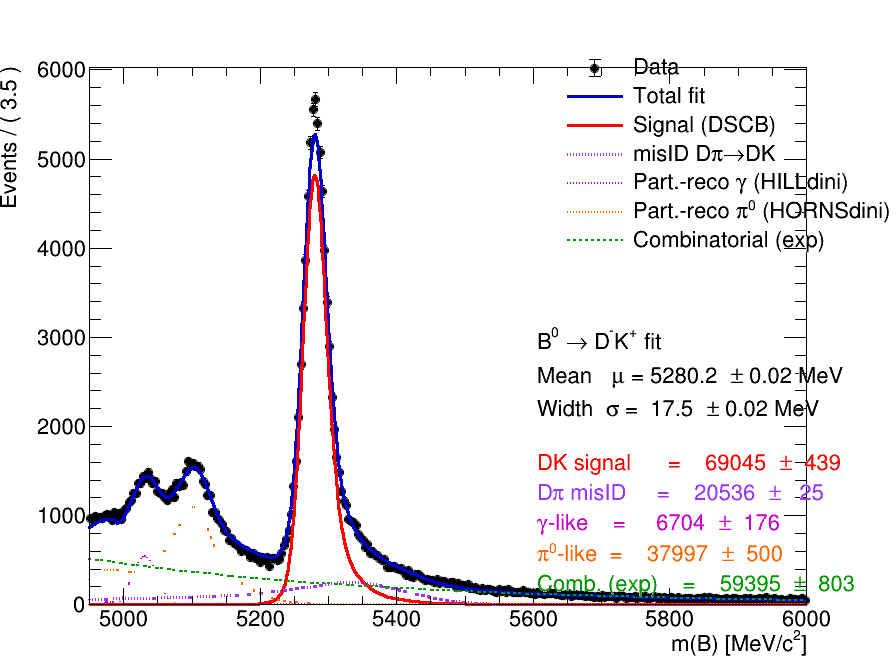

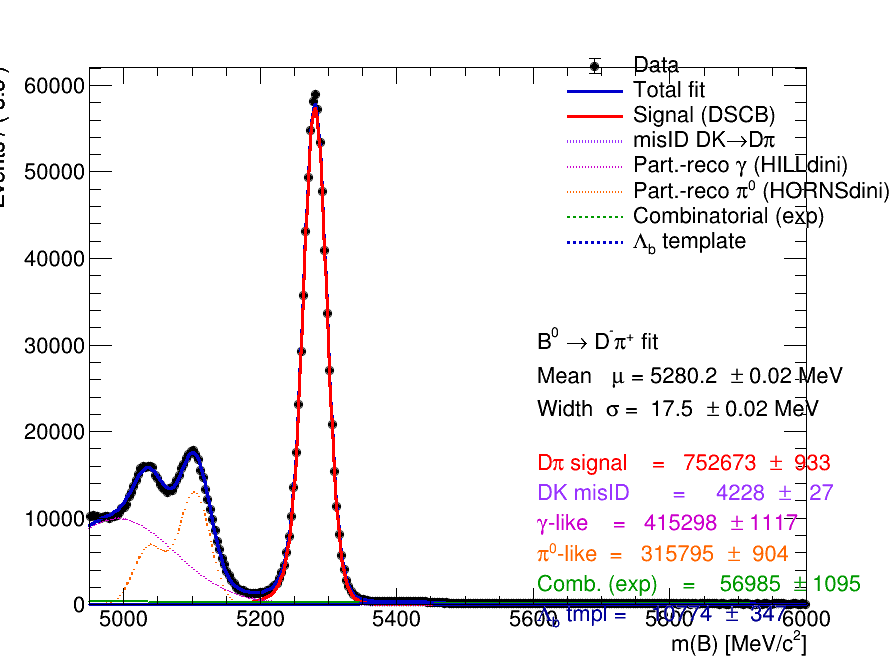

In [9]:
# ============================================================
# FULL PLOTTING CODE (both channels) — LHCb-like, no overlaps
#
# What this fixes (your two requests):
#  ✅ Add space between μ and σ lines in the yield box
#  ✅ Move/format the top title so it does NOT overlap the frame/lines
#     (we draw it as TLatex in the top margin, not inside the plot)
#  ✅ Yield box stays low-right, with extra line spacing between yields
#  ✅ Works for BOTH Dpi and DK with the same function
#
# Assumptions (already defined earlier in your notebook/script):
#  - m (RooRealVar), dh_Dpi, dh_DK, pdf_Dpi, pdf_DK
#  - comps_Dpi, comps_DK and helper _components_from_list(comps_*)
#  - mu_val, mu_err, sig_val, sig_err
#  - yield_lines_Dpi, yield_lines_DK (list of (string,color))
# ============================================================


# Keep drawn objects alive

def draw_title_top_margin(canvas, title, x=0.22, y=0.985, size=0.042):
    """
    Draw a clean title in the top margin so it never overlaps plot content.
    y ~ 0.985 puts it just under the top edge (inside pad), relying on top margin.
    """
    canvas.cd()
    t = ROOT.TLatex()
    t.SetNDC(True)
    t.SetTextFont(42)
    t.SetTextSize(size)
    t.SetTextAlign(13)  # left-top alignment
    t.DrawLatex(x, y, title)
    _PLOT_KEEP.append(t)
    return t


def draw_yield_box_low_right(pad, header_lines, body_lines,
                             # moved up a bit, taller
                             x1=0.58, y1=0.18, x2=0.95, y2=0.46,
                             text_size=0.030,
                             fill_alpha=0.80,
                             add_blank_after_each=True,
                             extra_blank_between_mu_sigma=True):
    """
    header_lines: list of (text, color)
    body_lines  : list of (text, color)

    Adds extra blank line between μ and σ if extra_blank_between_mu_sigma=True,
    and adds spacing between yields if add_blank_after_each=True.
    """
    pad.cd()
    box = ROOT.TPaveText(x1, y1, x2, y2, "NDC")
    box.SetBorderSize(0)
    box.SetTextAlign(12)
    box.SetTextFont(42)
    box.SetTextSize(text_size)

    # readable background without hiding too much
    try:
        box.SetFillColorAlpha(ROOT.kWhite, fill_alpha)
    except Exception:
        box.SetFillColor(ROOT.kWhite)
        box.SetFillStyle(1001)

    # ---- header (mu/sigma) with extra spacing
    if len(header_lines) >= 1:
        txt, col = header_lines[0]
        t = box.AddText(txt); t.SetTextColor(col)

    if extra_blank_between_mu_sigma:
        box.AddText(" ")  # <-- requested extra space between μ and σ

    if len(header_lines) >= 2:
        txt, col = header_lines[1]
        t = box.AddText(txt); t.SetTextColor(col)

    box.AddText(" ")  # space before yields

    # ---- yields with spacing
    for txt, col in body_lines:
        t = box.AddText(txt)
        t.SetTextColor(col)
        if add_blank_after_each:
            box.AddText(" ")

    box.Draw("same")
    _PLOT_KEEP.append(box)
    return box


def force_axis_titles_and_style(frame, n_bins, x_title, y_title=None):
    """
    Apply axis titles + robust styling (works with RooPlot).
    """
    ax = frame.GetXaxis()
    ay = frame.GetYaxis()

    ax.SetTitle(x_title)

    if y_title is None:
        binw = (float(m.getMax()) - float(m.getMin())) / float(n_bins)
        y_title = f"Candidates / {binw:.0f} MeV/#it{{c}}^{{2}}"
    ay.SetTitle(y_title)

    # ROOT-style sizes (fractions)
    ax.SetTitleFont(42); ay.SetTitleFont(42)
    ax.SetLabelFont(42); ay.SetLabelFont(42)

    ax.SetTitleSize(0.055); ay.SetTitleSize(0.055)
    ax.SetLabelSize(0.050); ay.SetLabelSize(0.050)

    ax.SetTitleOffset(1.10)
    ay.SetTitleOffset(2.20)   # ensure y-title never clashes with labels

    return frame


def plot_channel_final(tag, data, pdf, components, title,
                       yield_lines,
                       n_bins=60,
                       save_png=True,
                       save_pdf=True,
                       x_title="m(B) [MeV/#it{c}^{2}]",
                       y_title=None,
                       # legend top-right
                       legend_xy=(0.52, 0.52, 0.88, 0.82),
                       # yield box low-right
                       yield_box_xy=(0.58, 0.18, 0.95, 0.46),
                       # margins: more top margin for title in margin
                       margins=(0.24, 0.05, 0.16, 0.10)):
    """
    margins = (left, right, bottom, top)
    """
    left, right, bottom, top = margins

    c = ROOT.TCanvas(f"c_{tag}", f"{tag} fit", 1000, 750)
    c.SetLeftMargin(left)
    c.SetRightMargin(right)
    c.SetBottomMargin(bottom)
    c.SetTopMargin(top)
    c.SetTicks(1, 1)

    # Build RooPlot
    frame = m.frame(ROOT.RooFit.Title(""), ROOT.RooFit.Bins(int(n_bins)))

    # Data and total
    data.plotOn(frame, ROOT.RooFit.Name("data"))
    pdf.plotOn(frame, ROOT.RooFit.LineWidth(3), ROOT.RooFit.Name("total"))

    # Components
    for comp, col, sty, legend_label in components:
        pdf.plotOn(frame,
                   ROOT.RooFit.Components(comp.GetName()),
                   ROOT.RooFit.LineColor(col),
                   ROOT.RooFit.LineStyle(sty),
                   ROOT.RooFit.LineWidth(3),
                   ROOT.RooFit.Name(legend_label))

    # Draw first (RooPlot quirk), then force axis titles/styles
    frame.Draw()
    force_axis_titles_and_style(frame, n_bins, x_title=x_title, y_title=y_title)

    # Legend
    lx1, ly1, lx2, ly2 = legend_xy
    leg = ROOT.TLegend(lx1, ly1, lx2, ly2)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)
    leg.SetTextFont(42)
    leg.SetTextSize(0.038)
    leg.AddEntry(frame.findObject("data"),  "Data", "lep")
    leg.AddEntry(frame.findObject("total"), "Total fit", "l")
    for _, _, _, legend_label in components:
        leg.AddEntry(frame.findObject(legend_label), legend_label, "l")
    leg.Draw("same")
    _PLOT_KEEP.append(leg)

    # Title in top margin (no overlap with data/lines)
    draw_title_top_margin(c, title, x=left, y=0.985, size=0.046)

    # Yield box header (mu/sigma) + yields
    header = [
        (f"#mu = {mu_val:7.2f} #pm {mu_err:5.2f} MeV", ROOT.kBlack),
        (f"#sigma = {sig_val:6.2f} #pm {sig_err:5.2f} MeV", ROOT.kBlack),
    ]
    bx1, by1, bx2, by2 = yield_box_xy
    draw_yield_box_low_right(
        c, header, yield_lines,
        x1=bx1, y1=by1, x2=bx2, y2=by2,
        text_size=0.030,
        fill_alpha=0.80,
        add_blank_after_each=True,
        extra_blank_between_mu_sigma=True
    )

    # Force paint/update before saving (prevents missing titles/boxes in output)
    c.Modified()
    c.Update()

    # Re-apply axis titles once more after update (extra robust)
    force_axis_titles_and_style(frame, n_bins, x_title=x_title, y_title=y_title)
    c.Modified()
    c.Update()

    if save_png:
        c.SaveAs(f"{tag}_simfit.png")
    if save_pdf:
        c.SaveAs(f"{tag}_simfit.pdf")

    _PLOT_KEEP.append(c)
    return c


# ============================================================
# CALL FOR BOTH CHANNELS
# ============================================================

# DK
plot_channel_final(
    tag="DK",
    data=dh_DK,
    pdf=pdf_DK,
    components=_components_from_list(comps_DK),
    title="B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)",
    yield_lines=yield_lines_DK,
    n_bins=60,
    # If DK tail overlaps yield box in your setup, move the box slightly up:
    # yield_box_xy=(0.58, 0.22, 0.95, 0.50),
)

# Dpi
plot_channel_final(
    tag="Dpi",
    data=dh_Dpi,
    pdf=pdf_Dpi,
    components=_components_from_list(comps_Dpi),
    title="B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)",
    yield_lines=yield_lines_Dpi,
    n_bins=60,
)


[48 RooFit INFO/Eval messages suppressed for readability — see the message-service cell near the top of this notebook]



Info in <TCanvas::Print>: png file Dpi_log_clean.png has been created
Info in <TCanvas::Print>: pdf file Dpi_log_clean.pdf has been created
Info in <TCanvas::Print>: png file DK_log_clean.png has been created
Info in <TCanvas::Print>: pdf file DK_log_clean.pdf has been created



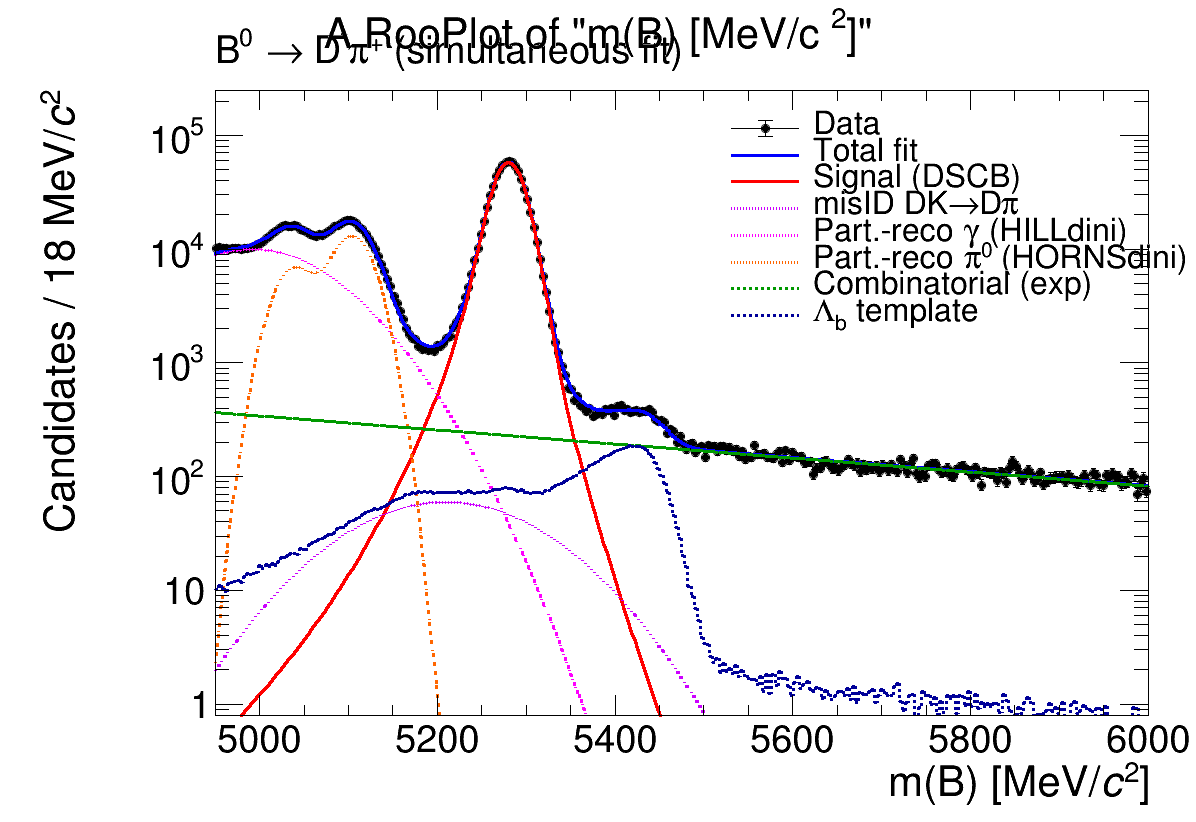

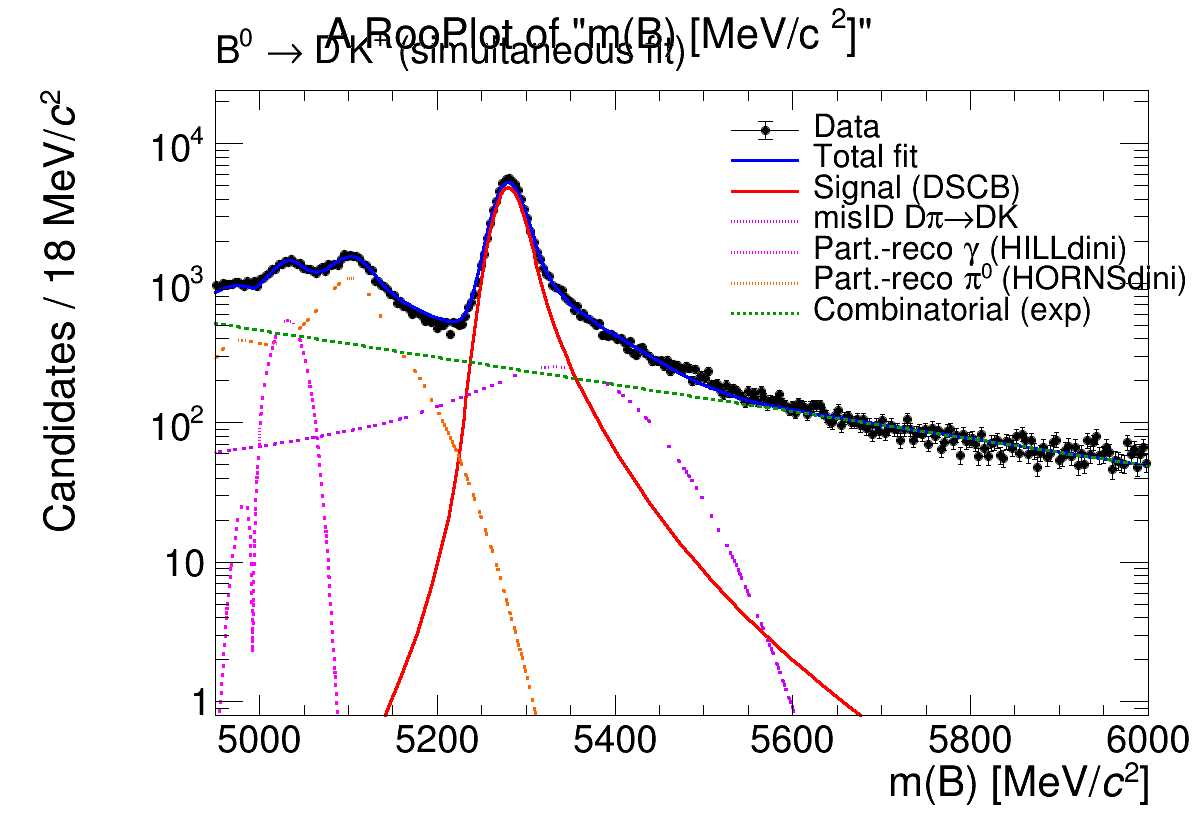

In [10]:
# ============================================================
# CLEAN LOG PLOT — LARGER CANVAS + LEGEND UP/RIGHT
# ============================================================


def plot_channel_log_clean(tag, data, pdf, components, title,
                           n_bins=60,
                           save_png=True,
                           save_pdf=True,
                           x_title="m(B) [MeV/#it{c}^{2}]",
                           y_title=None):

    # ---- Bigger canvas ----
    c = ROOT.TCanvas(f"c_{tag}_log_clean", f"{tag} log", 1200, 850)

    # Slightly tighter margins to enlarge plotting region
    c.SetLeftMargin(0.18)
    c.SetRightMargin(0.04)
    c.SetBottomMargin(0.13)
    c.SetTopMargin(0.11)

    c.SetTicks(1, 1)
    c.SetLogy()

    frame = m.frame(ROOT.RooFit.Title(""), ROOT.RooFit.Bins(int(n_bins)))

    data.plotOn(frame, ROOT.RooFit.Name("data"))
    pdf.plotOn(frame, ROOT.RooFit.LineWidth(3), ROOT.RooFit.Name("total"))

    for comp, col, sty, legend_label in components:
        pdf.plotOn(frame,
                   ROOT.RooFit.Components(comp.GetName()),
                   ROOT.RooFit.LineColor(col),
                   ROOT.RooFit.LineStyle(sty),
                   ROOT.RooFit.LineWidth(3),
                   ROOT.RooFit.Name(legend_label))

    frame.Draw()

    # ---- Log-safe limits ----
    frame.SetMinimum(0.8)
    frame.SetMaximum(frame.GetMaximum()*4)

    # ---- Axis titles ----
    ax = frame.GetXaxis()
    ay = frame.GetYaxis()

    ax.SetTitle(x_title)

    if y_title is None:
        binw = (float(m.getMax()) - float(m.getMin())) / float(n_bins)
        y_title = f"Candidates / {binw:.0f} MeV/#it{{c}}^{{2}}"

    ay.SetTitle(y_title)

    ax.SetTitleFont(42); ay.SetTitleFont(42)
    ax.SetLabelFont(42); ay.SetLabelFont(42)

    ax.SetTitleSize(0.055); ay.SetTitleSize(0.055)
    ax.SetLabelSize(0.050); ay.SetLabelSize(0.050)

    # Bring titles closer to axes
    ax.SetTitleOffset(0.95)
    ay.SetTitleOffset(1.50)

    # ---- Legend: shifted right and up ----
    leg = ROOT.TLegend(0.60, 0.60, 0.92, 0.86)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)
    leg.SetTextFont(42)
    leg.SetTextSize(0.042)

    leg.AddEntry(frame.findObject("data"),  "Data", "lep")
    leg.AddEntry(frame.findObject("total"), "Total fit", "l")

    for _, _, _, legend_label in components:
        leg.AddEntry(frame.findObject(legend_label), legend_label, "l")

    leg.Draw("same")
    _PLOT_KEEP_LOG.append(leg)

    # ---- Clear heading in top margin ----
    t = ROOT.TLatex()
    t.SetNDC(True)
    t.SetTextFont(42)
    t.SetTextSize(0.050)
    t.SetTextAlign(13)
    t.DrawLatex(0.18, 0.965, title)
    _PLOT_KEEP_LOG.append(t)

    c.Modified()
    c.Update()

    if save_png:
        c.SaveAs(f"{tag}_log_clean.png")
    if save_pdf:
        c.SaveAs(f"{tag}_log_clean.pdf")

    _PLOT_KEEP_LOG.append(c)
    return c


# ============================================================
# MAKE CLEAN LOG PLOTS
# ============================================================

plot_channel_log_clean(
    tag="Dpi",
    data=dh_Dpi,
    pdf=pdf_Dpi,
    components=_components_from_list(comps_Dpi),
    title="B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)"
)

plot_channel_log_clean(
    tag="DK",
    data=dh_DK,
    pdf=pdf_DK,
    components=_components_from_list(comps_DK),
    title="B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)"
)

---
## Stacked linear and logarithmic grid

Figure 5 of the report. Both channels, both scales, with the components drawn separately.


In [12]:
# ============================================================
# FULL CORRECTED CELL (RETURN FIXED): 2x2 STACKED-LOOK SIMFIT PLOTS
#   (1) Dpi linear (x cut optional)
#   (2) DK  linear (x cut optional)
#   (3) Dpi log    (full x-range)
#   (4) DK  log    (full x-range)
#
# - NO yield boxes
# - Explicit scale labels on each pad
# - Λb ALWAYS visible on Dπ:
#     include_Lb_in_stack=True  -> filled layer
#     include_Lb_in_stack=False -> dotted overlay (default)
# - Titles fixed to: \bar{B}^0 -> D^+ pi^- / D^+ K^- (ROOT TLatex syntax)
# - Fix: always returns (canvas, keepalive)
# - Saves under a DIFFERENT name via out_prefix argument below
# ============================================================


def make_simfit_stacked_grid(out_prefix="simfit_stacked_linear_and_log",
                             n_bins=60,
                             x_title="m(B) [MeV/#it{c}^{2}]",
                             include_Lb_in_stack=False,
                             cut_linear_x=True,
                             linear_xmax=5800.0):

    keep = []

    # -----------------------------
    # Helpers: style
    # -----------------------------
    def _set_lhcb_pad_style(pad, logy=False):
        pad.SetTicks(1, 1)
        pad.SetLeftMargin(0.18)
        pad.SetRightMargin(0.05)
        pad.SetBottomMargin(0.14)
        pad.SetTopMargin(0.12)
        pad.SetLogy(bool(logy))

    def _style_frame_axes(frame, x_title, y_title=None, x_off=0.95, y_off=1.55):
        ax = frame.GetXaxis()
        ay = frame.GetYaxis()

        ax.SetTitle(x_title)
        if y_title is None:
            # assumes your RooRealVar is called m (as in your notebook)
            binw = (float(m.getMax()) - float(m.getMin())) / float(n_bins)
            y_title = "Candidates / bin"
        ay.SetTitle(y_title)

        ax.SetTitleFont(42); ay.SetTitleFont(42)
        ax.SetLabelFont(42); ay.SetLabelFont(42)
        ax.SetTitleSize(0.060); ay.SetTitleSize(0.060)
        ax.SetLabelSize(0.055); ay.SetLabelSize(0.055)
        ax.SetTitleOffset(x_off)
        ay.SetTitleOffset(y_off)

    def _draw_title_in_margin(pad, title, scale_label):
        pad.cd()

        # Left: decay title (ROOT TLatex syntax; no $...$)
        t = ROOT.TLatex()
        t.SetNDC(True)
        t.SetTextFont(42)
        t.SetTextSize(0.055)
        t.SetTextAlign(13)
        t.DrawLatex(pad.GetLeftMargin(), 0.985, title)
        keep.append(t)

        # Right: explicit scale label
        t2 = ROOT.TLatex()
        t2.SetNDC(True)
        t2.SetTextFont(42)
        t2.SetTextSize(0.050)
        t2.SetTextAlign(33)
        t2.DrawLatex(1 - pad.GetRightMargin(), 0.985, scale_label)
        keep.append(t2)

    # -----------------------------
    # Helpers: stacked-like RooFit drawing
    # -----------------------------
    def draw_stacked_rooplot(frame, data, pdf,
                             cum_component_name_lists,
                             cum_fill_styles,
                             cum_fill_colors,
                             outline_components,
                             outline_colors,
                             outline_styles,
                             extra_overlay_components=None,
                             extra_overlay_colors=None,
                             extra_overlay_styles=None,
                             logy=False,
                             y_min_log=0.8):

        # Data
        data.plotOn(frame, RF.Name("data"), RF.MarkerSize(0.8))

        # Cumulative filled sums (bottom -> top)
        for names, fsty, fcol in zip(cum_component_name_lists, cum_fill_styles, cum_fill_colors):
            comp_str = ",".join(names)
            pdf.plotOn(frame,
                       RF.Components(comp_str),
                       RF.DrawOption("F"),
                       RF.FillStyle(int(fsty)),
                       RF.FillColor(int(fcol)),
                       RF.LineColor(int(fcol)),
                       RF.VLines(),
                       RF.MoveToBack())

        # Total line
        pdf.plotOn(frame, RF.LineColor(ROOT.kBlack), RF.LineWidth(3), RF.Name("total"))

        # Outlines (signal/misID/comb)
        for comp_name, col, sty in zip(outline_components, outline_colors, outline_styles):
            pdf.plotOn(frame, RF.Components(comp_name),
                       RF.LineColor(int(col)),
                       RF.LineStyle(int(sty)),
                       RF.LineWidth(3))

        # Extra overlays (e.g. Λb dotted)
        if extra_overlay_components:
            for comp_name, col, sty in zip(extra_overlay_components, extra_overlay_colors, extra_overlay_styles):
                pdf.plotOn(frame, RF.Components(comp_name),
                           RF.LineColor(int(col)),
                           RF.LineStyle(int(sty)),
                           RF.LineWidth(3))

        # Y-range
        if logy:
            frame.SetMinimum(y_min_log)
            frame.SetMaximum(frame.GetMaximum() * 4.0)
        else:
            frame.SetMinimum(0.0)
            frame.SetMaximum(frame.GetMaximum() * 1.15)

    # -----------------------------
    # Helpers: legend
    # -----------------------------
    def draw_stack_legend(pad, entries, xy=(0.58, 0.56, 0.93, 0.88), text_size=0.040):
        pad.cd()
        x1, y1, x2, y2 = xy
        leg = ROOT.TLegend(x1, y1, x2, y2)
        leg.SetBorderSize(0)
        leg.SetFillStyle(0)
        leg.SetTextFont(42)
        leg.SetTextSize(text_size)

        dummies = []
        for e in entries:
            kind = e.get("kind", "line")
            if kind == "data":
                g = ROOT.TGraph()
                g.SetMarkerStyle(20)
                g.SetMarkerSize(0.9)
                g.SetMarkerColor(ROOT.kBlack)
                leg.AddEntry(g, e["label"], "lep")
                dummies.append(g)
            elif kind == "line":
                l = ROOT.TLine(0, 0, 1, 0)
                l.SetLineColor(int(e.get("line_color", ROOT.kBlack)))
                l.SetLineStyle(int(e.get("line_style", 1)))
                l.SetLineWidth(int(e.get("line_width", 3)))
                leg.AddEntry(l, e["label"], "l")
                dummies.append(l)
            else:
                b = ROOT.TBox(0, 0, 1, 1)
                b.SetFillColor(int(e.get("fill_color", ROOT.kGray)))
                b.SetFillStyle(int(e.get("fill_style", 1001)))
                b.SetLineColor(int(e.get("line_color", ROOT.kBlack)))
                leg.AddEntry(b, e["label"], "f")
                dummies.append(b)

        leg.Draw("same")
        keep.append(leg)
        keep.extend(dummies)

    # -----------------------------
    # Colors / fill styles
    # -----------------------------
    COL_COMB = ROOT.kGreen + 2
    COL_PI0  = ROOT.kOrange + 7
    COL_GAM  = ROOT.kMagenta + 1
    COL_MIS  = ROOT.kAzure + 7
    COL_SIG  = ROOT.kBlue - 7
    COL_LB   = ROOT.kBlue + 2

    F_COMB = 1001
    F_PI0  = 1001
    F_GAM  = 1001
    F_MIS  = 1001
    F_SIG  = 3004

    # -----------------------------
    # Λb presence check (avoid NameError)
    # -----------------------------
    has_LB = ("LB_in_Dpi_shape" in globals())

    # -----------------------------
    # Dπ stack definition
    # -----------------------------
    cum_Dpi = [
        [BKG_comb_Dpi.GetName()],
        [BKG_comb_Dpi.GetName(), BKG_pi_Dpi.GetName()],
        [BKG_comb_Dpi.GetName(), BKG_pi_Dpi.GetName(), BKG_g_Dpi.GetName()],
        [BKG_comb_Dpi.GetName(), BKG_pi_Dpi.GetName(), BKG_g_Dpi.GetName(), MIS_Dpi.GetName()],
    ]
    fill_styles_Dpi = [F_COMB, F_PI0, F_GAM, F_MIS]
    fill_colors_Dpi = [COL_COMB, COL_PI0, COL_GAM, COL_MIS]

    # Optionally filled Λb layer
    if include_Lb_in_stack and has_LB:
        cum_Dpi.append([BKG_comb_Dpi.GetName(), BKG_pi_Dpi.GetName(), BKG_g_Dpi.GetName(),
                        MIS_Dpi.GetName(), LB_in_Dpi_shape.GetName()])
        fill_styles_Dpi.append(1001)
        fill_colors_Dpi.append(COL_LB)

    # Top hatched layer includes signal (+ Λb if filled)
    top_names_Dpi = [BKG_comb_Dpi.GetName(), BKG_pi_Dpi.GetName(), BKG_g_Dpi.GetName(), MIS_Dpi.GetName()]
    if include_Lb_in_stack and has_LB:
        top_names_Dpi.append(LB_in_Dpi_shape.GetName())
    top_names_Dpi.append(SIG_Dpi.GetName())

    cum_Dpi.append(top_names_Dpi)
    fill_styles_Dpi.append(F_SIG)
    fill_colors_Dpi.append(COL_SIG)

    outline_Dpi = [SIG_Dpi.GetName(), MIS_Dpi.GetName(), BKG_comb_Dpi.GetName()]
    outline_col_Dpi = [ROOT.kRed, ROOT.kViolet + 1, ROOT.kBlack]
    outline_sty_Dpi = [1, 2, 3]

    # If not filled: dotted overlay Λb so it is ALWAYS visible
    extra_overlay_Dpi = []
    extra_overlay_col_Dpi = []
    extra_overlay_sty_Dpi = []
    if (not include_Lb_in_stack) and has_LB:
        extra_overlay_Dpi = [LB_in_Dpi_shape.GetName()]
        extra_overlay_col_Dpi = [COL_LB]
        extra_overlay_sty_Dpi = [2]

    # -----------------------------
    # DK stack definition
    # -----------------------------
    cum_DK = [
        [BKG_comb_DK.GetName()],
        [BKG_comb_DK.GetName(), BKG_pi_DK.GetName()],
        [BKG_comb_DK.GetName(), BKG_pi_DK.GetName(), BKG_g_DK.GetName()],
        [BKG_comb_DK.GetName(), BKG_pi_DK.GetName(), BKG_g_DK.GetName(), MIS_DK.GetName()],
        [BKG_comb_DK.GetName(), BKG_pi_DK.GetName(), BKG_g_DK.GetName(), MIS_DK.GetName(), SIG_DK.GetName()],
    ]
    fill_styles_DK = [F_COMB, F_PI0, F_GAM, F_MIS, F_SIG]
    fill_colors_DK = [COL_COMB, COL_PI0, COL_GAM, COL_MIS, COL_SIG]

    outline_DK = [SIG_DK.GetName(), MIS_DK.GetName(), BKG_comb_DK.GetName()]
    outline_col_DK = [ROOT.kRed, ROOT.kViolet + 1, ROOT.kBlack]
    outline_sty_DK = [1, 2, 3]

    # -----------------------------
    # Legends
    # -----------------------------
    legend_entries_Dpi = [
        {"label": "Data", "kind": "data"},
        {"label": "Total fit", "kind": "line", "line_color": ROOT.kBlack, "line_style": 1, "line_width": 3},
        {"label": "Signal + bkg (top)", "kind": "fill", "fill_color": COL_SIG, "fill_style": F_SIG, "line_color": COL_SIG},
        {"label": "misID DK#rightarrowD#pi", "kind": "fill", "fill_color": COL_MIS, "fill_style": F_MIS, "line_color": COL_MIS},
        {"label": "Part.-reco #gamma", "kind": "fill", "fill_color": COL_GAM, "fill_style": F_GAM, "line_color": COL_GAM},
        {"label": "Part.-reco #pi^{0}", "kind": "fill", "fill_color": COL_PI0, "fill_style": F_PI0, "line_color": COL_PI0},
    ]
    if has_LB:
        if include_Lb_in_stack:
            legend_entries_Dpi.append({"label": "#Lambda_{b} template", "kind": "fill",
                                      "fill_color": COL_LB, "fill_style": 1001, "line_color": COL_LB})
        else:
            legend_entries_Dpi.append({"label": "#Lambda_{b} template", "kind": "line",
                                      "line_color": COL_LB, "line_style": 2, "line_width": 3})

    legend_entries_Dpi.append({"label": "Combinatorial", "kind": "fill",
                              "fill_color": COL_COMB, "fill_style": F_COMB, "line_color": COL_COMB})

    legend_entries_DK = [
        {"label": "Data", "kind": "data"},
        {"label": "Total fit", "kind": "line", "line_color": ROOT.kBlack, "line_style": 1, "line_width": 3},
        {"label": "Signal + bkg (top)", "kind": "fill", "fill_color": COL_SIG, "fill_style": F_SIG, "line_color": COL_SIG},
        {"label": "misID D#pi#rightarrowDK", "kind": "fill", "fill_color": COL_MIS, "fill_style": F_MIS, "line_color": COL_MIS},
        {"label": "Part.-reco #gamma", "kind": "fill", "fill_color": COL_GAM, "fill_style": F_GAM, "line_color": COL_GAM},
        {"label": "Part.-reco #pi^{0}", "kind": "fill", "fill_color": COL_PI0, "fill_style": F_PI0, "line_color": COL_PI0},
        {"label": "Combinatorial", "kind": "fill", "fill_color": COL_COMB, "fill_style": F_COMB, "line_color": COL_COMB},
    ]

    # -----------------------------
    # Canvas
    # -----------------------------
    c = ROOT.TCanvas("c_simfit_stacked_grid", "simfit stacked grid", 1800, 1200)
    c.Divide(2, 2, 0.0, 0.0)
    keep.append(c)

    def _make_frame(is_linear):
        fr = m.frame(RF.Title(""), RF.Bins(int(n_bins)))
        if is_linear and cut_linear_x:
            fr.SetAxisRange(float(m.getMin()), float(linear_xmax), "X")
        return fr

    # Titles (ROOT TLatex syntax)
    title_Dpi = "#bar{B}^{0} #rightarrow D^{+}#pi^{-}  (simultaneous fit)"
    title_DK  = "#bar{B}^{0} #rightarrow D^{+}K^{-}  (simultaneous fit)"

    # (1) Dpi linear
    p1 = c.cd(1); _set_lhcb_pad_style(p1, logy=False)
    frame1 = _make_frame(is_linear=True)
    draw_stacked_rooplot(frame1, dh_Dpi, pdf_Dpi,
                         cum_Dpi, fill_styles_Dpi, fill_colors_Dpi,
                         outline_Dpi, outline_col_Dpi, outline_sty_Dpi,
                         extra_overlay_components=extra_overlay_Dpi,
                         extra_overlay_colors=extra_overlay_col_Dpi,
                         extra_overlay_styles=extra_overlay_sty_Dpi,
                         logy=False)
    frame1.Draw()
    _style_frame_axes(frame1, x_title=x_title)
    _draw_title_in_margin(p1, title_Dpi, "Linear scale")
    draw_stack_legend(p1, legend_entries_Dpi)
    keep.append(frame1)

    # (2) DK linear
    p2 = c.cd(2); _set_lhcb_pad_style(p2, logy=False)
    frame2 = _make_frame(is_linear=True)
    draw_stacked_rooplot(frame2, dh_DK, pdf_DK,
                         cum_DK, fill_styles_DK, fill_colors_DK,
                         outline_DK, outline_col_DK, outline_sty_DK,
                         logy=False)
    frame2.Draw()
    _style_frame_axes(frame2, x_title=x_title)
    _draw_title_in_margin(p2, title_DK, "Linear scale")
    draw_stack_legend(p2, legend_entries_DK)
    keep.append(frame2)

    # (3) Dpi log
    p3 = c.cd(3); _set_lhcb_pad_style(p3, logy=True)
    frame3 = _make_frame(is_linear=False)
    draw_stacked_rooplot(frame3, dh_Dpi, pdf_Dpi,
                         cum_Dpi, fill_styles_Dpi, fill_colors_Dpi,
                         outline_Dpi, outline_col_Dpi, outline_sty_Dpi,
                         extra_overlay_components=extra_overlay_Dpi,
                         extra_overlay_colors=extra_overlay_col_Dpi,
                         extra_overlay_styles=extra_overlay_sty_Dpi,
                         logy=True, y_min_log=0.8)
    frame3.Draw()
    _style_frame_axes(frame3, x_title=x_title)
    _draw_title_in_margin(p3, title_Dpi, "Logarithmic scale")
    draw_stack_legend(p3, legend_entries_Dpi)
    keep.append(frame3)

    # (4) DK log
    p4 = c.cd(4); _set_lhcb_pad_style(p4, logy=True)
    frame4 = _make_frame(is_linear=False)
    draw_stacked_rooplot(frame4, dh_DK, pdf_DK,
                         cum_DK, fill_styles_DK, fill_colors_DK,
                         outline_DK, outline_col_DK, outline_sty_DK,
                         logy=True, y_min_log=0.8)
    frame4.Draw()
    _style_frame_axes(frame4, x_title=x_title)
    _draw_title_in_margin(p4, title_DK, "Logarithmic scale")
    draw_stack_legend(p4, legend_entries_DK)
    keep.append(frame4)

    c.Modified()
    c.Update()

    c.SaveAs(f"{out_prefix}.png")
    c.SaveAs(f"{out_prefix}.pdf")

    return c, keep


# ---- run ----
# Saved under a DIFFERENT name:
canvas_stacked, keepalive = make_simfit_stacked_grid(
    out_prefix="simfit_stacked_linear_and_log_xmax5800_B0bar_titles",
    n_bins=60,
    include_Lb_in_stack=False,  # Λb dotted overlay in Dπ
    cut_linear_x=True,
    linear_xmax=5800.0
)


[144 RooFit INFO/Eval messages suppressed for readability — see the message-service cell near the top of this notebook]



Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_simfit_stacked_grid
Info in <TCanvas::Print>: png file simfit_stacked_linear_and_log_xmax5800_B0bar_titles.png has been created
Info in <TCanvas::Print>: pdf file simfit_stacked_linear_and_log_xmax5800_B0bar_titles.pdf has been created



---
## $\Lambda_b^0$ control fit

Figure 6 of the report. Johnson $S_U$ signal, Bernstein combinatorial, a HORNS partially
reconstructed component and a small Gaussian $\Lambda_c^+ K^-$ cross-feed. The fitted yield is
what normalises the $\Lambda_b^0$ template used above.


In [13]:

ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetOptTitle(0)
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)


def plot_lb_control_fit_note(
    outname="Lb_control_fit_note_clean",
    nbins=130,
    title_linear="#Lambda_{b}^{0} #rightarrow #Lambda_{c}^{+}#pi^{-} (linear)",
    title_log   ="#Lambda_{b}^{0} #rightarrow #Lambda_{c}^{+}#pi^{-} (log)",
):

    COL_TOTAL = ROOT.kBlack
    COL_SIG   = ROOT.kAzure + 2
    COL_COMB  = ROOT.kGray + 1
    COL_PART  = ROOT.kSpring + 5
    COL_LCK   = ROOT.kOrange + 7

    ndata = dh_Lb_true.sumEntries()
    normN = RF.Normalization(ndata, ROOT.RooAbsReal.NumEvent)

    c = ROOT.TCanvas("c_Lb_control_note", "Lb control fit", 1500, 550)
    c.Divide(2, 1, 0.01, 0.01)

    pads = [c.cd(1), c.cd(2)]
    for p in pads:
        p.SetLeftMargin(0.17)     # ↑ increased from 0.13
        p.SetRightMargin(0.04)
        p.SetBottomMargin(0.14)
        p.SetTopMargin(0.12)

    def _draw_one(pad, is_log=False, title=""):
        pad.cd()
        pad.SetLogy(is_log)

        frame = mLb.frame(RF.Bins(nbins))

        frame.GetXaxis().SetTitle("m(#Lambda_{b}) [MeV/c^{2}]")
        bw = (mLb.getMax() - mLb.getMin()) / float(nbins)
        frame.GetYaxis().SetTitle("Candidates / bin ")

        frame.GetXaxis().SetTitleSize(0.060)
        frame.GetYaxis().SetTitleSize(0.060)

        frame.GetXaxis().SetLabelSize(0.048)
        frame.GetYaxis().SetLabelSize(0.045)

        # 🔥 Critical fix
        frame.GetYaxis().SetTitleOffset(1.55)  # move title further left

        # ---- Filled components ----
        model_Lb.plotOn(frame,
                        RF.Components(comb_Lb.GetName()),
                        RF.DrawOption("F"),
                        RF.FillColor(COL_COMB),
                        RF.FillStyle(1001),
                        RF.VLines(),
                        RF.LineColor(COL_COMB),
                        normN)

        model_Lb.plotOn(frame,
                        RF.Components(part_Lb.GetName()),
                        RF.DrawOption("F"),
                        RF.FillColor(COL_PART),
                        RF.FillStyle(1001),
                        RF.VLines(),
                        RF.LineColor(COL_PART),
                        normN)

        model_Lb.plotOn(frame,
                        RF.Components(lck_Lb.GetName()),
                        RF.DrawOption("F"),
                        RF.FillColor(COL_LCK),
                        RF.FillStyle(1001),
                        RF.VLines(),
                        RF.LineColor(COL_LCK),
                        normN)

        model_Lb.plotOn(frame,
                        RF.LineColor(COL_TOTAL),
                        RF.LineWidth(4),
                        normN)

        model_Lb.plotOn(frame,
                        RF.Components(sig_Lb.GetName()),
                        RF.LineColor(COL_SIG),
                        RF.LineWidth(4),
                        RF.LineStyle(ROOT.kDotted),
                        normN)

        dh_Lb_true.plotOn(frame,
                          RF.MarkerStyle(20),
                          RF.MarkerSize(0.85),
                          RF.LineColor(ROOT.kBlack))

        if is_log:
            frame.SetMinimum(1.0)

        frame.Draw()

        tt = ROOT.TLatex()
        tt.SetNDC(True)
        tt.SetTextFont(42)
        tt.SetTextSize(0.060)
        tt.DrawLatex(0.18, 0.94, title)
        _LB_PLOT_KEEP.append(tt)

        # ---- Legend ----
        key_data = ROOT.TGraph(); key_data.SetMarkerStyle(20)
        key_tot  = ROOT.TLine(0,0,1,0); key_tot.SetLineColor(COL_TOTAL); key_tot.SetLineWidth(4)
        key_sig  = ROOT.TLine(0,0,1,0); key_sig.SetLineColor(COL_SIG); key_sig.SetLineStyle(ROOT.kDotted); key_sig.SetLineWidth(4)
        key_comb = ROOT.TBox(0,0,1,1); key_comb.SetFillColor(COL_COMB)
        key_part = ROOT.TBox(0,0,1,1); key_part.SetFillColor(COL_PART)
        key_lck  = ROOT.TBox(0,0,1,1); key_lck.SetFillColor(COL_LCK)

        _LB_PLOT_KEEP.extend([key_data,key_tot,key_sig,key_comb,key_part,key_lck])

        leg = ROOT.TLegend(0.60, 0.60, 0.92, 0.88)
        leg.SetBorderSize(0)
        leg.SetFillStyle(0)
        leg.SetTextFont(42)
        leg.SetTextSize(0.045)

        leg.AddEntry(key_data, "Data", "p")
        leg.AddEntry(key_tot,  "Total fit", "l")
        leg.AddEntry(key_sig,  "Signal (JohnsonSU)", "l")
        leg.AddEntry(key_comb, "Combinatorial", "f")
        leg.AddEntry(key_part, "PartReco (merged)", "f")
        leg.AddEntry(key_lck,  "#Lambda_{c}K (misID)", "f")

        leg.Draw()
        _LB_PLOT_KEEP.append(leg)

        pad.Update()

    _draw_one(pads[0], False, title_linear)
    _draw_one(pads[1], True,  title_log)

    c.SaveAs(outname + ".png")
    c.SaveAs(outname + ".pdf")
    print(f"Saved: {outname}.png and {outname}.pdf")


plot_lb_control_fit_note(
    outname="Lb_control_fit_note_clean",
    nbins=LB_NBINS if "LB_NBINS" in globals() else 130
)

Saved: Lb_control_fit_note_clean.png and Lb_control_fit_note_clean.pdf

[38 RooFit INFO/Eval messages suppressed for readability — see the message-service cell near the top of this notebook]



Info in <TCanvas::Print>: png file Lb_control_fit_note_clean.png has been created
Info in <TCanvas::Print>: pdf file Lb_control_fit_note_clean.pdf has been created



# EXTRA

---
# 5. From yields to branching fractions

The fitted yields are combined with the external inputs of Eq. (2), $f_u/f_d = 1$, the
luminosity scale factor $f_L = 1112.6/403.468 = 2.76$, and the relative tracking efficiency
$\varepsilon_{\mathrm{rel}}$.

$\varepsilon_{\mathrm{rel}}$ does not cancel completely: the signal final state has four
charged tracks against three in the normalisation channel, so one power of the muon baseline
efficiency survives (Eqs. 9–10).

Uncertainties are propagated with `uncertainties` and separated into three categories by
toggling each group of inputs independently — statistical from the fitted yields, experimental
from the tracking efficiency, external from the PDG branching fractions.


In [14]:

pkg = "uncertainties"
spec = importlib.util.find_spec(pkg)

if spec is None:
    print("Package NOT installed.")
else:
    print("Package is installed at:")
    print(spec.origin)


Package is installed at:
/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/uncertainties/__init__.py



In [15]:
# After fit
vNsig_Dpi, eNsig_Dpi = yields["Nsig_Dpi"]
vNmis_Dpi, eNmis_Dpi = yields["Nmis_Dpi"]
vNg_Dpi,   eNg_Dpi   = yields["Ng_Dpi"]
vNpi_Dpi,  eNpi_Dpi  = yields["Npi_Dpi"]
vNcomb_Dpi,eNcomb_Dpi= yields["Ncomb_Dpi"]
vNlb,      eNlb      = yields["N_LB_in_Dpi"]

vNsig_DK, eNsig_DK = yields["Nsig_DK"]
vNmis_DK, eNmis_DK = yields["Nmis_DK"]
vNg_DK,   eNg_DK   = yields["Ng_DK"]
vNpi_DK,  eNpi_DK  = yields["Npi_DK"]
vNcomb_DK,eNcomb_DK= yields["Ncomb_DK"]

COL_SIG = ROOT.kRed
COL_MIS = ROOT.kViolet+1
COL_G   = ROOT.kMagenta+1
COL_PI0 = ROOT.kOrange+7
COL_COMB= ROOT.kGreen+2
COL_LB  = ROOT.kBlue+2

yield_lines_Dpi = [
    (f"D#pi signal    = {vNsig_Dpi:8.0f}  #pm {eNsig_Dpi:4.0f}", COL_SIG),
    (f"DK misID       = {vNmis_Dpi:8.0f}  #pm {eNmis_Dpi:4.0f}", COL_MIS),
    (f"#gamma-like    = {vNg_Dpi:8.0f}  #pm {eNg_Dpi:4.0f}",     COL_G),
    (f"#pi^{{0}}-like  = {vNpi_Dpi:8.0f}  #pm {eNpi_Dpi:4.0f}",  COL_PI0),
    (f"Comb. (exp)    = {vNcomb_Dpi:8.0f}  #pm {eNcomb_Dpi:4.0f}", COL_COMB),
    (f"#Lambda_{{b}} tmpl = {vNlb:8.0f}  #pm {eNlb:4.0f}",       COL_LB),
]

yield_lines_DK = [
    (f"DK signal      = {vNsig_DK:8.0f}  #pm {eNsig_DK:4.0f}", COL_SIG),
    (f"D#pi misID     = {vNmis_DK:8.0f}  #pm {eNmis_DK:4.0f}", COL_MIS),
    (f"#gamma-like    = {vNg_DK:8.0f}  #pm {eNg_DK:4.0f}",     COL_G),
    (f"#pi^{{0}}-like  = {vNpi_DK:8.0f}  #pm {eNpi_DK:4.0f}",  COL_PI0),
    (f"Comb. (exp)    = {vNcomb_DK:8.0f}  #pm {eNcomb_DK:4.0f}", COL_COMB),
]


In [16]:

# ============================================================
# PLOTTING (CRASH FIX): plot per-channel PDFs, not simPdf with Slice/ProjWData
# ============================================================
print("\n[plot] making safe per-channel plots...")

COL_TOTAL = ROOT.kBlue+1
COL_SIG   = ROOT.kRed
COL_BKG   = ROOT.kGreen+2
COL_LB    = ROOT.kMagenta+2

def plot_one_channel_refstyle(tag, var, datahist, pdf, out_pdf,
                              yield_lines,   # list of (text, color)
                              mean_val, mean_err,
                              sig_val,  sig_err,
                              title_main):
    c = ROOT.TCanvas(f"c_{tag}", tag, 900, 700)
    _KEEPALIVE.append(c)

    frame = var.frame(RF.Title(title_main), RF.Bins(60))
    _KEEPALIVE.append(frame)

    # --- Data ---
    datahist.plotOn(frame,
                    RF.Name("data"),
                    RF.MarkerStyle(20),
                    RF.MarkerSize(1.0))

    # --- Total ---
    COL_TOTAL = ROOT.kBlue+1
    pdf.plotOn(frame,
               RF.LineColor(COL_TOTAL),
               RF.LineWidth(3),
               RF.Name("total"))

    # --- Components (match reference styling) ---
    COL_SIG   = ROOT.kRed
    COL_MIS   = ROOT.kViolet+1
    COL_PART  = ROOT.kMagenta+1
    COL_PI0   = ROOT.kOrange+7
    COL_COMB  = ROOT.kGreen+2
    COL_LB    = ROOT.kBlue+2  # (your screenshot uses a blue dashed-ish for Λb; tweak if you want)

    # Signal
    pdf.plotOn(frame,
               RF.Components("SIG_"+tag),
               RF.LineColor(COL_SIG),
               RF.LineWidth(3),
               RF.Name("sig"))

    # misID
    pdf.plotOn(frame,
               RF.Components("MIS_"+tag),
               RF.LineColor(COL_MIS),
               RF.LineStyle(ROOT.kDotted),
               RF.LineWidth(3),
               RF.Name("mis"))

    # partial reco γ
    pdf.plotOn(frame,
               RF.Components("BKG_g_"+tag),
               RF.LineColor(COL_PART),
               RF.LineStyle(ROOT.kDotted),
               RF.LineWidth(2),
               RF.Name("g"))

    # partial reco π0
    pdf.plotOn(frame,
               RF.Components("BKG_pi_"+tag),
               RF.LineColor(COL_PI0),
               RF.LineStyle(ROOT.kDotted),
               RF.LineWidth(2),
               RF.Name("pi0"))

    # combinatorial
    pdf.plotOn(frame,
               RF.Components("BKG_comb_"+tag),
               RF.LineColor(COL_COMB),
               RF.LineStyle(ROOT.kDashed),
               RF.LineWidth(2),
               RF.Name("comb"))

    # Λb only for Dpi
    if tag == "Dpi":
        pdf.plotOn(frame,
                   RF.Components("LB_in_Dpi_shape"),
                   RF.LineColor(COL_TOTAL),   # blue like your screenshot
                   RF.LineStyle(ROOT.kDashed),
                   RF.LineWidth(3),
                   RF.Name("lb"))

    frame.Draw()

    # --- Legend (same ordering/labels as reference) ---
    leg = ROOT.TLegend(0.62, 0.62, 0.97, 0.92)
    _KEEPALIVE.append(leg)
    leg.SetFillStyle(0); leg.SetBorderSize(0)
    leg.SetTextFont(42); leg.SetTextSize(0.035)

    def obj(n): return frame.findObject(n)
    leg.AddEntry(obj("data"),  "Data", "pe")
    leg.AddEntry(obj("total"), "Total fit", "l")
    leg.AddEntry(obj("sig"),   "Signal (DSCB)", "l")
    if tag == "Dpi":
        leg.AddEntry(obj("mis"), "misID DK#rightarrowD#pi", "l")
    else:
        leg.AddEntry(obj("mis"), "misID D#pi#rightarrowDK", "l")
    leg.AddEntry(obj("g"),     "Part.-reco #gamma (HILLdini)", "l")
    leg.AddEntry(obj("pi0"),   "Part.-reco #pi^{0} (HORNSdini)", "l")
    leg.AddEntry(obj("comb"),  "Combinatorial (exp)", "l")
    if tag == "Dpi":
        leg.AddEntry(obj("lb"), "#Lambda_{b} template", "l")
    leg.Draw()

    # --- Parameter + yield box (TLatex) ---
    latex = ROOT.TLatex()
    _KEEPALIVE.append(latex)
    latex.SetNDC(True)
    latex.SetTextFont(42)
    latex.SetTextSize(0.035)

    x0, y0 = 0.60, 0.48
    latex.SetTextColor(ROOT.kBlack)
    latex.DrawLatex(x0, y0, f"B^{{0}} #rightarrow D^{{-}}{('#pi^{+}' if tag=='Dpi' else 'K^{+}')} fit")
    latex.DrawLatex(x0, y0-0.05, f"Mean   #mu = {mean_val:6.1f}  #pm {mean_err:4.2f} MeV")
    latex.DrawLatex(x0, y0-0.10, f"Width  #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV")

    # colored yield lines (like screenshot)
    yy = y0 - 0.18
    for text, col in yield_lines:
        latex.SetTextColor(col)
        latex.DrawLatex(x0, yy, text)
        yy -= 0.045

    c.SaveAs(out_pdf)
    print("  wrote", out_pdf)



[plot] making safe per-channel plots...



In [17]:
# IMPORTANT: component names must match exactly (SIG_Dpi, MIS_Dpi, etc).
# Easiest fix: rename your PDFs to SIG_Dpi, MIS_Dpi, ... exactly as below:
#  - in your simfit you already have SIG_Dpi, MIS_Dpi, SIG_DK, MIS_DK, BKG_g_Dpi,...

plot_one_channel_refstyle(
    tag="Dpi",
    var=m,
    datahist=dh_Dpi,
    pdf=pdf_Dpi,
    out_pdf="fit_Dpi_sim.pdf",
    yield_lines=yield_lines_Dpi,
    mean_val=mu.getVal(), mean_err=mu.getError(),
    sig_val=sig.getVal(), sig_err=sig.getError(),
    title_main="B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)"
)

plot_one_channel_refstyle(
    tag="DK",
    var=m,
    datahist=dh_DK,
    pdf=pdf_DK,
    out_pdf="fit_DK_sim.pdf",
    yield_lines=yield_lines_DK,
    mean_val=mu.getVal(), mean_err=mu.getError(),
    sig_val=sig.getVal(), sig_err=sig.getError(),
    title_main="B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)"
)


  wrote fit_Dpi_sim.pdf
  wrote fit_DK_sim.pdf

[48 RooFit INFO/Eval messages suppressed for readability — see the message-service cell near the top of this notebook]



Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_Dpi
Info in <TCanvas::Print>: pdf file fit_Dpi_sim.pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_DK
Info in <TCanvas::Print>: pdf file fit_DK_sim.pdf has been created



In [19]:
# NOTE: three-way split (stat / exp / ext). Cell below defines a two-way
# (stat / ext) variant under a different name; both are used.

# -----------------------------
# Central values + uncertainties
# -----------------------------
# Yields (STAT errors)
N_Dpi_c,  N_Dpi_s  = 752673.0, 933.0
N_DK_c,   N_DK_s   = 69045.0, 439.0
N_norm_c, N_norm_s = 136071.0, 428.0

# External factor(s)
f276_c, f276_s = 2.76, 0.0
fd_over_fu_c, fd_over_fu_s = 1.0, 0.0

# PDG inputs for R_B (EXTERNAL errors)
BF_Bp_JpsiK_c,  BF_Bp_JpsiK_s  = 1.020e-3, 0.019e-3
BF_Jpsi_mumu_c, BF_Jpsi_mumu_s = 0.05961,  0.00033
BF_Dp_Kpipi_c,  BF_Dp_Kpipi_s  = 0.0946,   0.0024

# Detector / material-interaction inputs
eps_mu_c, eps_mu_s = 0.969, 0.0

# Material-interaction fractions: treat as EXPERIMENTAL systematics
fhad_pi_c, fhad_pi_s = 0.150, 0.004
fhad_K_c,  fhad_K_s  = 0.127, 0.003
fhad_Knorm_c, fhad_Knorm_s = fhad_K_c, fhad_K_s

# -----------------------------
# PDG values to compare against
# -----------------------------
PDG_Dpi = ufloat(2.51e-3, 0.08e-3)  # B0 -> D- pi+
PDG_DK  = ufloat(2.05e-4, 0.08e-4)  # B0 -> D- K+

# -----------------------------
# Compute BFs with control over
# which uncertainty class is on
# -----------------------------
def compute_bfs(stat_on=True, exp_on=True, ext_on=True):
    # -----------------
    # STAT uncertainties
    # -----------------
    N_Dpi  = ufloat(N_Dpi_c,  N_Dpi_s  if stat_on else 0.0)
    N_DK   = ufloat(N_DK_c,   N_DK_s   if stat_on else 0.0)
    N_norm = ufloat(N_norm_c, N_norm_s if stat_on else 0.0)

    # ------------------------
    # EXPERIMENTAL systematics
    # ------------------------
    eps_mu     = ufloat(eps_mu_c,     eps_mu_s     if exp_on else 0.0)
    fhad_pi    = ufloat(fhad_pi_c,    fhad_pi_s    if exp_on else 0.0)
    fhad_K     = ufloat(fhad_K_c,     fhad_K_s     if exp_on else 0.0)
    fhad_Knorm = ufloat(fhad_Knorm_c, fhad_Knorm_s if exp_on else 0.0)

    # ----------------
    # EXTERNAL inputs
    # ----------------
    f276       = ufloat(f276_c,       f276_s       if ext_on else 0.0)
    fd_over_fu = ufloat(fd_over_fu_c, fd_over_fu_s if ext_on else 0.0)

    BF_Bp_JpsiK  = ufloat(BF_Bp_JpsiK_c,  BF_Bp_JpsiK_s  if ext_on else 0.0)
    BF_Jpsi_mumu = ufloat(BF_Jpsi_mumu_c, BF_Jpsi_mumu_s if ext_on else 0.0)
    BF_Dp_Kpipi  = ufloat(BF_Dp_Kpipi_c,  BF_Dp_Kpipi_s  if ext_on else 0.0)

    # R_B and effective norm
    R_B = (BF_Bp_JpsiK * BF_Jpsi_mumu) / BF_Dp_Kpipi
    N_norm_eff = f276 * N_norm

    # per-track efficiencies from hadronic fractions
    eps_trk_pi    = eps_mu * (1 - fhad_pi)
    eps_trk_K     = eps_mu * (1 - fhad_K)
    eps_trk_Knorm = eps_mu * (1 - fhad_Knorm)

    # tracking ratio
    def eps_trk_rel(eps_trk_h):
        return (eps_mu**2 * eps_trk_Knorm) / (eps_trk_K * eps_trk_pi**2 * eps_trk_h)

    eps_rel_pi = eps_trk_rel(eps_trk_pi)
    eps_rel_K  = eps_trk_rel(eps_trk_K)

    # BF formula
    BF_Dpi = fd_over_fu * (N_Dpi / N_norm_eff) * R_B * eps_rel_pi
    BF_DK  = fd_over_fu * (N_DK  / N_norm_eff) * R_B * eps_rel_K

    return BF_Dpi, BF_DK


# -----------------------------
# Same split for eps_rel only
# -----------------------------
def compute_epsrels_stat_exp_ext(stat_on=True, exp_on=True, ext_on=True):
    # stat_on not used here, kept only for interface consistency

    # EXPERIMENTAL systematics
    eps_mu     = ufloat(eps_mu_c,     eps_mu_s     if exp_on else 0.0)
    fhad_pi    = ufloat(fhad_pi_c,    fhad_pi_s    if exp_on else 0.0)
    fhad_K     = ufloat(fhad_K_c,     fhad_K_s     if exp_on else 0.0)
    fhad_Knorm = ufloat(fhad_Knorm_c, fhad_Knorm_s if exp_on else 0.0)

    # per-track efficiencies
    eps_trk_pi    = eps_mu * (1 - fhad_pi)
    eps_trk_K     = eps_mu * (1 - fhad_K)
    eps_trk_Knorm = eps_mu * (1 - fhad_Knorm)

    def eps_trk_rel(eps_trk_h):
        return (eps_mu**2 * eps_trk_Knorm) / (eps_trk_K * eps_trk_pi**2 * eps_trk_h)

    eps_rel_pi = eps_trk_rel(eps_trk_pi)
    eps_rel_K  = eps_trk_rel(eps_trk_K)

    return eps_rel_pi, eps_rel_K


# -----------------------------
# Split: STAT / EXP / EXT
# -----------------------------
BF_Dpi_stat, BF_DK_stat = compute_bfs(stat_on=True,  exp_on=False, ext_on=False)
BF_Dpi_exp,  BF_DK_exp  = compute_bfs(stat_on=False, exp_on=True,  ext_on=False)
BF_Dpi_ext,  BF_DK_ext  = compute_bfs(stat_on=False, exp_on=False, ext_on=True)
BF_Dpi_cen,  BF_DK_cen  = compute_bfs(stat_on=False, exp_on=False, ext_on=False)


def combine3(cen, stat, exp, ext):
    s_stat = stat.s
    s_exp  = exp.s
    s_ext  = ext.s
    s_tot  = math.sqrt(s_stat**2 + s_exp**2 + s_ext**2)
    return ufloat(cen.n, s_tot), s_stat, s_exp, s_ext


BF_Dpi_tot, BF_Dpi_s_stat, BF_Dpi_s_exp, BF_Dpi_s_ext = combine3(
    BF_Dpi_cen, BF_Dpi_stat, BF_Dpi_exp, BF_Dpi_ext
)
BF_DK_tot, BF_DK_s_stat, BF_DK_s_exp, BF_DK_s_ext = combine3(
    BF_DK_cen, BF_DK_stat, BF_DK_exp, BF_DK_ext
)

# eps_rel split
epsrel_pi_stat, epsrel_K_stat = compute_epsrels_stat_exp_ext(stat_on=True,  exp_on=False, ext_on=False)
epsrel_pi_exp,  epsrel_K_exp  = compute_epsrels_stat_exp_ext(stat_on=False, exp_on=True,  ext_on=False)
epsrel_pi_ext,  epsrel_K_ext  = compute_epsrels_stat_exp_ext(stat_on=False, exp_on=False, ext_on=True)
epsrel_pi_cen,  epsrel_K_cen  = compute_epsrels_stat_exp_ext(stat_on=False, exp_on=False, ext_on=False)

epsrel_pi_tot, epsrel_pi_s_stat, epsrel_pi_s_exp, epsrel_pi_s_ext = combine3(
    epsrel_pi_cen, epsrel_pi_stat, epsrel_pi_exp, epsrel_pi_ext
)
epsrel_K_tot, epsrel_K_s_stat, epsrel_K_s_exp, epsrel_K_s_ext = combine3(
    epsrel_K_cen, epsrel_K_stat, epsrel_K_exp, epsrel_K_ext
)

# -----------------------------
# Formatting helpers
# -----------------------------
def sci_parts(x: ufloat):
    """Return (mantissa, mantissa_err, exponent) with x = mantissa * 10^exponent."""
    if x.n == 0:
        return 0.0, x.s, 0
    exp = int(math.floor(math.log10(abs(x.n))))
    m   = x.n / (10**exp)
    me  = x.s / (10**exp)
    return m, me, exp

def print_bf(label, x_tot, s_stat, s_exp, s_ext):
    m, me, exp = sci_parts(x_tot)
    m_stat = s_stat / (10**exp)
    m_exp  = s_exp  / (10**exp)
    m_ext  = s_ext  / (10**exp)
    print(
        f"{label} = ({m:.4f} ± {m_stat:.4f}_stat ± {m_exp:.4f}_exp ± {m_ext:.4f}_ext) × 10^{exp}"
    )

def pct_diff(meas: ufloat, pdg: ufloat):
    """Percent difference (meas-pdg)/pdg * 100 with propagated uncertainty."""
    return (meas / pdg - 1) * 100


# -----------------------------
# Results
# -----------------------------
print("\nBranching fractions (scientific notation):\n")
print_bf("B(B0 → Dπ)", BF_Dpi_tot, BF_Dpi_s_stat, BF_Dpi_s_exp, BF_Dpi_s_ext)
print_bf("B(B0 → DK)", BF_DK_tot,  BF_DK_s_stat,  BF_DK_s_exp,  BF_DK_s_ext)

print("\nRelative tracking efficiencies:\n")
print(
    f"eps_rel(Dpi) = {epsrel_pi_tot.n:.6f} ± {epsrel_pi_s_stat:.6f} (stat) ± "
    f"{epsrel_pi_s_exp:.6f} (exp) ± {epsrel_pi_s_ext:.6f} (ext)"
)
print(
    f"eps_rel(DK)  = {epsrel_K_tot.n:.6f} ± {epsrel_K_s_stat:.6f} (stat) ± "
    f"{epsrel_K_s_exp:.6f} (exp) ± {epsrel_K_s_ext:.6f} (ext)"
)

print("\nPercent difference relative to PDG:\n")
dDpi = pct_diff(BF_Dpi_tot, PDG_Dpi)
dDK  = pct_diff(BF_DK_tot,  PDG_DK)

print(f"Dπ : {dDpi.n:+.2f} ± {dDpi.s:.2f} %")
print(f"DK : {dDK.n:+.2f} ± {dDK.s:.2f} %")


Branching fractions (scientific notation):

B(B0 → Dπ) = (2.1646 ± 0.0073_stat ± 0.0323_exp ± 0.0692_ext) × 10^-3
B(B0 → DK) = (1.9333 ± 0.0137_stat ± 0.0235_exp ± 0.0618_ext) × 10^-4

Relative tracking efficiencies:

eps_rel(Dpi) = 1.680426 ± 0.000000 (stat) ± 0.025090 (exp) ± 0.000000 (ext)
eps_rel(DK)  = 1.636154 ± 0.000000 (stat) ± 0.019880 (exp) ± 0.000000 (ext)

Percent difference relative to PDG:

Dπ : -13.76 ± 4.11 %
DK : -5.69 ± 4.94 %



In [20]:
# --- New: compute eps_rel (value + uncertainty) for Dpi and DK ---

def compute_epsrels_stat_ext(stat_on=True, ext_on=True):
    # STAT (yields) -- not used in eps_rel, but keep structure consistent
    _ = ufloat(N_Dpi_c,  N_Dpi_s  if stat_on else 0.0)
    _ = ufloat(N_DK_c,   N_DK_s   if stat_on else 0.0)
    _ = ufloat(N_norm_c, N_norm_s if stat_on else 0.0)

    # EXTERNALS (these DO enter eps_rel through eps_mu and fhad_*)
    eps_mu    = ufloat(eps_mu_c,    eps_mu_s    if ext_on else 0.0)
    fhad_pi   = ufloat(fhad_pi_c,   fhad_pi_s   if ext_on else 0.0)
    fhad_K    = ufloat(fhad_K_c,    fhad_K_s    if ext_on else 0.0)
    fhad_Knorm = ufloat(fhad_Knorm_c, fhad_Knorm_s if ext_on else 0.0)

    # per-track effs from f_had
    eps_trk_pi    = eps_mu * (1 - fhad_pi)
    eps_trk_K     = eps_mu * (1 - fhad_K)
    eps_trk_Knorm = eps_mu * (1 - fhad_Knorm)

    # tracking ratio (from your slide), with h = pi or K
    def eps_trk_rel(eps_trk_h):
        return (eps_mu**2 * eps_trk_Knorm) / (eps_trk_K * eps_trk_pi**2 * eps_trk_h)

    eps_rel_pi = eps_trk_rel(eps_trk_pi)
    eps_rel_K  = eps_trk_rel(eps_trk_K)

    return eps_rel_pi, eps_rel_K


# Split: STAT vs EXTERNAL vs CENTRAL (same pattern you used for BF)
epsrel_pi_stat, epsrel_K_stat = compute_epsrels_stat_ext(stat_on=True,  ext_on=False)
epsrel_pi_ext,  epsrel_K_ext  = compute_epsrels_stat_ext(stat_on=False, ext_on=True)
epsrel_pi_cen,  epsrel_K_cen  = compute_epsrels_stat_ext(stat_on=False, ext_on=False)

# Combine in quadrature
def combine_ufloat(cen, stat, ext):
    s_stat = stat.s
    s_ext  = ext.s
    s_tot  = math.sqrt(s_stat**2 + s_ext**2)
    return ufloat(cen.n, s_tot), s_stat, s_ext

epsrel_pi_tot, epsrel_pi_s_stat, epsrel_pi_s_ext = combine_ufloat(epsrel_pi_cen, epsrel_pi_stat, epsrel_pi_ext)
epsrel_K_tot,  epsrel_K_s_stat,  epsrel_K_s_ext  = combine_ufloat(epsrel_K_cen,  epsrel_K_stat,  epsrel_K_ext)

print("Relative tracking efficiencies:\n")
print(f"eps_rel(Dpi) = {epsrel_pi_tot.n:.6f} ± {epsrel_pi_s_stat:.6f} (stat) ± {epsrel_pi_s_ext:.6f} (ext)")
print(f"eps_rel(DK)  = {epsrel_K_tot.n:.6f} ± {epsrel_K_s_stat:.6f} (stat) ± {epsrel_K_s_ext:.6f} (ext)")

Relative tracking efficiencies:

eps_rel(Dpi) = 1.680426 ± 0.000000 (stat) ± 0.025090 (ext)
eps_rel(DK)  = 1.636154 ± 0.000000 (stat) ± 0.019880 (ext)



---
## Ratio $\mathcal{B}(D^+K^-)/\mathcal{B}(D^+\pi^-)$

Several external inputs and efficiency factors cancel in the ratio, so it is a complementary
comparison to the two individual branching fractions.


In [21]:
# --------------------------------
# Ratio R = B(B0 -> DK) / B(B0 -> Dπ)
# --------------------------------

R_B = BF_DK_tot / BF_Dpi_tot

print("Ratio of branching fractions:\n")
print(f"B_DK / B_Dπ = ({R_B.n:.4f} ± {R_B.s:.4f})")

# scientific notation if desired
def sci_ratio(x):
    exp = int(math.floor(math.log10(abs(x.n))))
    m   = x.n / 10**exp
    me  = x.s / 10**exp
    return m, me, exp

m, me, exp = sci_ratio(R_B)

print(f"\nScientific notation:")
print(f"B_DK / B_Dπ = ({m:.3f} ± {me:.3f}) × 10^{exp}")

Ratio of branching fractions:

B_DK / B_Dπ = (0.0893 ± 0.0044)

Scientific notation:
B_DK / B_Dπ = (8.932 ± 0.444) × 10^-2



---
# 6. Comparison with world averages and projection to 30 fb$^{-1}$

The $D^+K^-$ result agrees with the PDG average within uncertainties; $D^+\pi^-$ sits below it.

Scaling the statistical uncertainty as $1/\sqrt{\mathcal{L}}$ to the full Run 3 dataset shows
the limiting factor: even at 30 fb$^{-1}$ the total uncertainty stays dominated by the external
branching-fraction inputs. More luminosity alone does not improve the measurement much.


In [23]:

# -------------------------------------------------
# Final quoted branching-fraction results
# -------------------------------------------------
BF_Dpi_c = 2.1646e-3
BF_Dpi_stat = 0.0073e-3
BF_Dpi_exp  = 0.0323e-3
BF_Dpi_ext  = 0.0692e-3

BF_DK_c = 1.9333e-4
BF_DK_stat = 0.0137e-4
BF_DK_exp  = 0.0235e-4
BF_DK_ext  = 0.0618e-4

# -------------------------------------------------
# Build ufloat objects for each uncertainty class
# -------------------------------------------------
BF_Dpi_stat_u = ufloat(BF_Dpi_c, BF_Dpi_stat)
BF_Dpi_exp_u  = ufloat(BF_Dpi_c, BF_Dpi_exp)
BF_Dpi_ext_u  = ufloat(BF_Dpi_c, BF_Dpi_ext)
BF_Dpi_cen_u  = ufloat(BF_Dpi_c, 0.0)

BF_DK_stat_u = ufloat(BF_DK_c, BF_DK_stat)
BF_DK_exp_u  = ufloat(BF_DK_c, BF_DK_exp)
BF_DK_ext_u  = ufloat(BF_DK_c, BF_DK_ext)
BF_DK_cen_u  = ufloat(BF_DK_c, 0.0)

# -------------------------------------------------
# Ratio for each component
# -------------------------------------------------
R_cen  = BF_DK_cen_u  / BF_Dpi_cen_u
R_stat = BF_DK_stat_u / BF_Dpi_stat_u
R_exp  = BF_DK_exp_u  / BF_Dpi_exp_u
R_ext  = BF_DK_ext_u  / BF_Dpi_ext_u

# -------------------------------------------------
# Extract split uncertainties
# -------------------------------------------------
R_s_stat = R_stat.s
R_s_exp  = R_exp.s
R_s_ext  = R_ext.s

R_tot_s = math.sqrt(R_s_stat**2 + R_s_exp**2 + R_s_ext**2)
R_tot   = ufloat(R_cen.n, R_tot_s)

# -------------------------------------------------
# Print result
# -------------------------------------------------
print("Branching-fraction ratio:\n")
print(
    f"B(B0 → DK) / B(B0 → Dπ) = "
    f"{R_tot.n:.6f} ± {R_s_stat:.6f} (stat) ± {R_s_exp:.6f} (exp) ± {R_s_ext:.6f} (ext)"
)

print("\nRelative uncertainties on the ratio:")
print(f"stat : {100 * R_s_stat / R_tot.n:.2f} %")
print(f"exp  : {100 * R_s_exp  / R_tot.n:.2f} %")
print(f"ext  : {100 * R_s_ext  / R_tot.n:.2f} %")
print(f"tot  : {100 * R_tot.s  / R_tot.n:.2f} %")

Branching-fraction ratio:

B(B0 → DK) / B(B0 → Dπ) = 0.089314 ± 0.000701 (stat) ± 0.001719 (exp) ± 0.004038 (ext)

Relative uncertainties on the ratio:
stat : 0.78 %
exp  : 1.92 %
ext  : 4.52 %
tot  : 4.98 %



In [24]:

# your result
R_meas = 0.089314
stat = 0.000701
exp  = 0.001719
ext  = 0.004038

sigma_meas = math.sqrt(stat**2 + exp**2 + ext**2)

# reference value (8.22%)
R_ref = 0.0822
ref_stat = 0.0011
ref_syst = 0.0025

sigma_ref = math.sqrt(ref_stat**2 + ref_syst**2)

# sigma deviation
sigma_comb = math.sqrt(sigma_meas**2 + sigma_ref**2)
sigma_dev = abs(R_meas - R_ref) / sigma_comb

print(f"Combined uncertainty = {sigma_comb:.5f}")
print(f"Sigma deviation = {sigma_dev:.2f} σ")


Combined uncertainty = 0.00522
Sigma deviation = 1.36 σ



In [25]:

# your result
R_meas = 0.089314
stat = 0.000701
exp  = 0.001719
ext  = 0.004038

sigma_meas = math.sqrt(stat**2 + exp**2 + ext**2)

# reference
R_ref = 8.19e-2
sigma_ref = 0.20e-2

# difference
delta = abs(R_meas - R_ref)

# combined uncertainty
sigma_comb = math.sqrt(sigma_meas**2 + sigma_ref**2)

# sigma deviation
sigma_dev = delta / sigma_comb

print("Sigma deviation =", sigma_dev)

Sigma deviation = 1.521262861556069



In [26]:

# =====================================
# Current measured values (from your fit)
# =====================================
BF_Dpi_c  = 2.1646e-3
BF_Dpi_stat = 0.0073e-3
BF_Dpi_ext  = 0.0764e-3

BF_DK_c   = 1.9333e-4
BF_DK_stat = 0.0137e-4
BF_DK_ext  = 0.0661e-4

# =====================================
# Luminosity scaling: 1 fb^-1 -> 30 fb^-1
# =====================================
scale = 30.0
stat_scale = 1.0 / math.sqrt(scale)

BF_Dpi_stat_new = BF_Dpi_stat * stat_scale
BF_DK_stat_new  = BF_DK_stat  * stat_scale

# =====================================
# Helper for scientific notation
# =====================================
def sci_format(c, stat, ext):
    exp = int(math.floor(math.log10(abs(c))))
    m   = c   / 10**exp
    ms  = stat/ 10**exp
    me  = ext / 10**exp
    return m, ms, me, exp

# =====================================
# Format results
# =====================================
m_pi, ms_pi, me_pi, e_pi = sci_format(BF_Dpi_c, BF_Dpi_stat_new, BF_Dpi_ext)
m_k,  ms_k,  me_k,  e_k  = sci_format(BF_DK_c,  BF_DK_stat_new,  BF_DK_ext)

print("\nBranching fractions projected to 30 fb^-1:\n")

print(f"B(B0 → Dπ) = ({m_pi:.4f} ± {ms_pi:.4f}_stat ± {me_pi:.4f}_ext) × 10^{e_pi}")
print(f"B(B0 → DK)  = ({m_k:.4f} ± {ms_k:.4f}_stat ± {me_k:.4f}_ext) × 10^{e_k}")

print("\nStatistical reduction factor =", stat_scale)



Branching fractions projected to 30 fb^-1:

B(B0 → Dπ) = (2.1646 ± 0.0013_stat ± 0.0764_ext) × 10^-3
B(B0 → DK)  = (1.9333 ± 0.0025_stat ± 0.0661_ext) × 10^-4

Statistical reduction factor = 0.18257418583505536



In [27]:
# NOTE: compares projected statistical precision against the PDG uncertainty.
# The cell below compares central values as well, under a different name.

# =====================================
# Your projected (30 fb^-1) STAT errors
# (numbers you printed)
# =====================================
BF_Dpi_stat_30 = 0.0013e-3
BF_DK_stat_30  = 0.0025e-4

# =====================================
# PDG uncertainties from your screenshot
#  B0 -> D- pi+ : (2.51 ± 0.08) × 10^-3
#  B0 -> D- K+  : (2.05 ± 0.08) × 10^-4
# Treat these as the PDG total error (use as comparison "PDG error")
# =====================================
PDG_Dpi_err = 0.08e-3
PDG_DK_err  = 0.08e-4

def compare_stat_precision(stat_meas, err_pdg, label):
    ratio = err_pdg / stat_meas                # "how many times smaller is your stat?"
    improvement_pct = (1.0 - stat_meas/err_pdg) * 100.0
    print(f"{label}:")
    print(f"  PDG quoted uncertainty     = {err_pdg:.2e}")
    print(f"  Your projected stat (30fb) = {stat_meas:.2e}")
    print(f"  Improvement factor (PDG/you) = {ratio:.2f}×")
    print(f"  Your stat is {improvement_pct:.1f}% smaller than PDG uncertainty\n")

print("Comparison of your projected STAT error vs PDG quoted uncertainty:\n")
compare_stat_precision(BF_Dpi_stat_30, PDG_Dpi_err, "B0 → Dπ")
compare_stat_precision(BF_DK_stat_30,  PDG_DK_err,  "B0 → DK")


Comparison of your projected STAT error vs PDG quoted uncertainty:

B0 → Dπ:
  PDG quoted uncertainty     = 8.00e-05
  Your projected stat (30fb) = 1.30e-06
  Improvement factor (PDG/you) = 61.54×
  Your stat is 98.4% smaller than PDG uncertainty

B0 → DK:
  PDG quoted uncertainty     = 8.00e-06
  Your projected stat (30fb) = 2.50e-07
  Improvement factor (PDG/you) = 32.00×
  Your stat is 96.9% smaller than PDG uncertainty



In [28]:

# ===============================
# Your projected 30 fb^-1 stat errors
# ===============================
BF_Dpi_central = 2.1646e-3
BF_DK_central  = 1.9333e-4

BF_Dpi_stat_30 = 0.0013e-3
BF_DK_stat_30  = 0.0025e-4

# ===============================
# PDG 2025 values (from screenshot)
# ===============================
PDG_Dpi_central = 2.51e-3
PDG_Dpi_err     = 0.08e-3

PDG_DK_central  = 2.05e-4
PDG_DK_err      = 0.08e-4

def compare_with_pdg(label, your_stat, pdg_err, your_central, pdg_central):
    
    # Absolute comparison
    factor = pdg_err / your_stat
    
    # Relative precision comparison
    rel_your = your_stat / your_central
    rel_pdg  = pdg_err / pdg_central
    rel_factor = rel_pdg / rel_your
    
    print(f"\n{label}")
    print("-" * 40)
    print(f"PDG total uncertainty       = {pdg_err:.2e}")
    print(f"Your projected stat (30fb)  = {your_stat:.2e}")
    print(f"Absolute improvement factor = {factor:.1f} × smaller\n")
    
    print("Relative precision comparison:")
    print(f"PDG relative uncertainty    = {rel_pdg:.3%}")
    print(f"Your relative stat          = {rel_your:.3%}")
    print(f"Relative improvement factor = {rel_factor:.1f} × better")

print("Comparison of projected statistical precision vs PDG\n")

compare_with_pdg("B0 → Dπ",
        BF_Dpi_stat_30, PDG_Dpi_err,
        BF_Dpi_central, PDG_Dpi_central)

compare_with_pdg("B0 → DK",
        BF_DK_stat_30, PDG_DK_err,
        BF_DK_central, PDG_DK_central)


Comparison of projected statistical precision vs PDG

B0 → Dπ
----------------------------------------
PDG total uncertainty       = 8.00e-05
Your projected stat (30fb)  = 1.30e-06
Absolute improvement factor = 61.5 × smaller

Relative precision comparison:
PDG relative uncertainty    = 3.187%
Your relative stat          = 0.060%
Relative improvement factor = 53.1 × better

B0 → DK
----------------------------------------
PDG total uncertainty       = 8.00e-06
Your projected stat (30fb)  = 2.50e-07
Absolute improvement factor = 32.0 × smaller

Relative precision comparison:
PDG relative uncertainty    = 3.902%
Your relative stat          = 0.129%
Relative improvement factor = 30.2 × better

